# Проект: Телекоммуникации

# Описание проекта: телекоммуникации

Оператор связи «ТелеДом» хочет бороться с оттоком клиентов. Для этого его сотрудники начнут предлагать промокоды и специальные условия всем, кто планирует отказаться от услуг связи. 

**Цель работы**

Построить модель, которая будет предсказывать, разорвёт ли абонент договор.\
При этом для оценки качества модели выберем ROC-AUC c порогом отсечки >= 0.85\
Для интерпритации и объясненния значений для заказчика вычислим Accuracy для лучшей модели.

**Описание услуг оператора**

Оператор предоставляет два основных типа услуг: 
- Стационарную телефонную связь (один телефон или несколько линий).
- Интернет (**DSL** или **Fiber optic**).

Дополнительные услуги:
- Интернет-безопасность: антивирус (**DeviceProtection**) и блокировка небезопасных сайтов (**OnlineSecurity**);
- Выделенная линия технической поддержки (**TechSupport**);
- Облачное хранилище файлов для резервного копирования данных (**OnlineBackup**);
- Стриминговое телевидение (**StreamingTV**) и каталог фильмов (**StreamingMovies**).

Клиенты могут платить за услуги каждый месяц или заключить договор на 1–2 года. Возможно оплатить счёт разными способами, а также получить электронный чек.

**Данные представлены в нескольких файлах**

- `contract_new.csv` — информация о договоре;
- `personal_new.csv` — персональные данные клиента;
- `internet_new.csv` — информация об интернет-услугах;
- `phone_new.csv` — информация об услугах телефонии.

**Файл `contract_new.csv`**

- `customerID` — идентификатор абонента;
- `BeginDate` — дата начала действия договора;
- `EndDate` — дата окончания действия договора;
- `Type` — тип оплаты: раз в год-два или ежемесячно;
- `PaperlessBilling` — электронный расчётный лист;
- `PaymentMethod` — тип платежа;
- `MonthlyCharges` — расходы за месяц;
- `TotalCharges` — общие расходы абонента.

**Файл `personal_new.csv`**

- `customerID` — идентификатор пользователя;
- `gender` — пол;
- `SeniorCitizen` — является ли абонент пенсионером;
- `Partner` — есть ли у абонента супруг или супруга;
- `Dependents` — есть ли у абонента дети.

**Файл `internet_new.csv`**

- `customerID` — идентификатор пользователя;
- `InternetService` — тип подключения;
- `OnlineSecurity` — блокировка опасных сайтов;
- `OnlineBackup` — облачное хранилище файлов для резервного копирования данных;
- `DeviceProtection` — антивирус;
- `TechSupport` — выделенная линия технической поддержки;
- `StreamingTV` — стриминговое телевидение;
- `StreamingMovies` — каталог фильмов.

**Файл `phone_new.csv`**

- `customerID` — идентификатор пользователя;
- `MultipleLines` — подключение телефона к нескольким линиям одновременно.

Во всех файлах столбец `customerID` содержит код клиента. Информация о договорах актуальна на 1 февраля 2020 года.

**План выполнения работы**

1. Загрузка данных
2. Исследовательский анализ и предобработка данных
3. Объединение данных
4. Исследовательский анализ и предобработка данных объединённого датафрейма
5. Подготовка данных
6. Обучение моделей машинного обучения
7. Выбор лучшей модели
8. Общий вывод и рекомендации заказчику

## Загрузка данных

### Обновление библиотек

In [1]:
!pip install --upgrade scikit-learn==1.3.0 -q

### Загрузка библиотек

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore')

try:
    import phik
except:
    !pip install phik -q
    import phik
    
from sklearn.model_selection import (train_test_split, 
                                     RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (MinMaxScaler,
                                   OneHotEncoder, 
                                   RobustScaler,
                                   StandardScaler
                                  )
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (confusion_matrix,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             roc_curve,
                             roc_auc_score)

from sklearn.ensemble import RandomForestClassifier 

try:
    from lightgbm import LGBMClassifier
except:
    !pip install lightgbm -q
    from lightgbm import LGBMClassifier

try:
    from catboost import CatBoostClassifier
except:
    !pip install catboost -q
    from catboost import CatBoostClassifier

from sklearn.dummy import DummyClassifier

In [3]:
RANDOM_STATE =120126

### Загрузка данных

In [4]:
pth_11 = '/datasets/contract_new.csv'
pth_12 = 'https://code.s3.yandex.net/datasets/contract_new.csv'

if os.path.exists(pth_11):
    contract_new = pd.read_csv(pth_11)
else:
    contract_new = pd.read_csv(pth_12)
    
display(contract_new.head())
contract_new.info()
print(f'----------\nПубликаты: {contract_new.duplicated().sum()}')

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB
----------
Публикаты: 0


In [5]:
pth_21 = '/datasets/personal_new.csv'
pth_22 = 'https://code.s3.yandex.net/datasets/personal_new.csv'

if os.path.exists(pth_21):
    personal_new = pd.read_csv(pth_21)
else:
    personal_new = pd.read_csv(pth_22)
    
display(personal_new.head())
personal_new.info()
print(f'----------\nПовторы: {personal_new.duplicated().sum()}')

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB
----------
Повторы: 0


In [6]:
pth_31 = '/datasets/internet_new.csv'
pth_32 = 'https://code.s3.yandex.net/datasets/internet_new.csv'

if os.path.exists(pth_31):
    internet_new = pd.read_csv(pth_31)
else:
    internet_new = pd.read_csv(pth_32)
    
display(internet_new.head())
internet_new.info()
print(f'----------\nПовторы: {internet_new.duplicated().sum()}')

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB
----------
Повторы: 0


In [7]:
pth_41 = '/datasets/phone_new.csv'
pth_42 = 'https://code.s3.yandex.net/datasets/phone_new.csv'

if os.path.exists(pth_41):
    phone_new = pd.read_csv(pth_41)
else:
    phone_new = pd.read_csv(pth_42)
    
display(phone_new.head())
phone_new.info()
print(f'----------\nПовторы: {phone_new.duplicated().sum()}')

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB
----------
Повторы: 0


#### Вывод по загрузке данных

* В данных нет явных дубликатов.
* Все таблицы заполнены без пропусков.
* Названия колонок в стиле Pascal допустимы, но нужно исправить gender в таблице personal_new и customerID во всех таблицах.
* Бинарные признаки со значениями 'Yes'/'No' следует заменить на 1/0.

Таблица contract_new:

* Поля BeginDate и EndDate типа object, нужно преобразовать в datetime.
* Поле TotalCharges нужно перевести в float64.
* Поле EndDate является целевым: если там есть дата, значит, клиент отказался от услуг связи.

Этот этап позволяет перейти к предобработке и анализу данных.

## Исследовательский анализ и предобработка данных

### Приведем названия всех столбцов к стилю Pascal

In [8]:
contract_new.rename(columns = {'customerID':'CustomerId'}, inplace = True)
contract_new.info()
personal_new.rename(columns = {'customerID':'CustomerId', 'gender':'Gender'}, inplace = True)
personal_new.info()
internet_new.rename(columns = {'customerID':'CustomerId', 'StreamingTV':'StreamingTv'}, inplace = True)
internet_new.info()
phone_new.rename(columns = {'customerID':'CustomerId'}, inplace = True)
phone_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerId        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerId     7043 non-null   object
 1   Gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   D

### Таблица `contract_new`

Найдем строковое значение в столбце `TotalCharges` заменим его на число и приведем столбец к типу float

In [9]:
sorted(contract_new['TotalCharges'].unique())[:5]

[' ', '100.17', '100.19', '100.2', '100.24']

Строковое значение пробел в данных `' '`\
Выведем строки содержашие это значение, для принятия решения по ним.

In [10]:
contract_new[contract_new['TotalCharges']==' ']

,CustomerId,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
488,4472-LVYGI,2020-02-01,No,Two year,Yes,Bank transfer (automatic),52.55,
753,3115-CZMZD,2020-02-01,No,Two year,No,Mailed check,20.25,
936,5709-LVOEQ,2020-02-01,No,Two year,No,Mailed check,80.85,
1082,4367-NUYAO,2020-02-01,No,Two year,No,Mailed check,25.75,
1340,1371-DWPAZ,2020-02-01,No,Two year,No,Credit card (automatic),56.05,
3331,7644-OMVMY,2020-02-01,No,Two year,No,Mailed check,19.85,
3826,3213-VVOLG,2020-02-01,No,Two year,No,Mailed check,25.35,
4380,2520-SGTTA,2020-02-01,No,Two year,No,Mailed check,20.00,
5218,2923-ARZLG,2020-02-01,No,One year,Yes,Mailed check,19.70,
6670,4075-WKNIU,2020-02-01,No,Two year,No,Mailed check,73.35,


Поскольку данные о договорах актуальны на 1 февраля 2020 года, дата 2020-02-01 в колонке BeginDate указывает на начало нового месяца. Клиенты только что заключили договор, и месяц еще не завершен. В таких случаях можно поставить значение из колонки MonthlyCharges или ноль, если проплаты еще не было. Примем решение заполнить столбец нулем и привести его к типу данных float.

In [11]:
contract_new['TotalCharges'].replace(' ', '0', inplace=True)
contract_new['TotalCharges'] = contract_new['TotalCharges'].astype(float)
contract_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerId        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   float64
dtypes: float64(2), object(6)
memory usage: 440.3+ KB


Описательная статистика числовых величин

In [12]:
contract_new.describe()

,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000
mean,64.761692,2115.312885
std,30.090047,2112.742814
min,18.250000,0.000000
25%,35.500000,436.750000
50%,70.350000,1343.350000
75%,89.850000,3236.690000
max,118.750000,9221.380000


Построим боксплот и гистограммы числовых величин

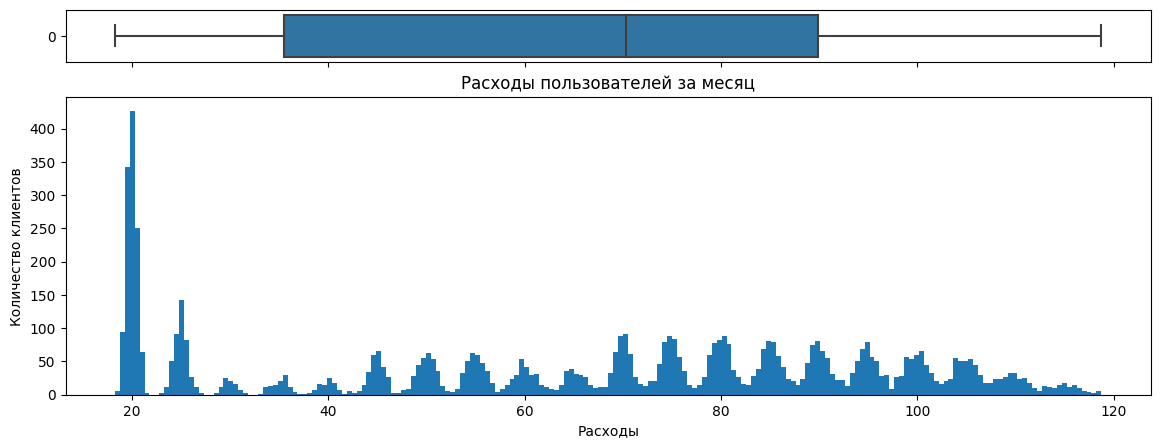

In [13]:
def f_hist_box(data, bins, title, xlabel, ylabel):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, figsize=(14,5), gridspec_kw={"height_ratios": (.15, .85)})
    sns.boxplot(data=[data], orient="h", ax=ax_box)
    plt.hist(data, bins=bins, range=(data.min(),data.max()))
 
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()
    
f_hist_box(
    data=contract_new['MonthlyCharges'],
    bins=200, 
    title='Расходы пользователей за месяц',
    xlabel='Расходы',
    ylabel='Количество клиентов'
)

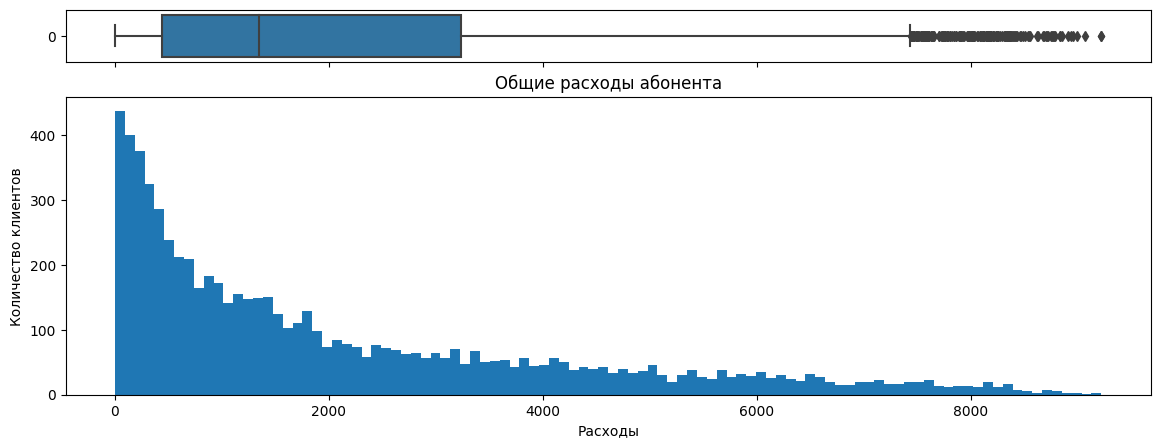

In [14]:
f_hist_box(
    data=contract_new['TotalCharges'],
    bins=100, 
    title='Общие расходы абонента',
    xlabel='Расходы',
    ylabel='Количество клиентов'
)

В распределении значений месячной оплаты `MonthlyCharges` наблюдается дискретность и бимодальность
- максимум количества клиентов с месячными тратами находится у значения 20, далее прослеживается снижение с последующей стабилизацией количества клиентов по месячным тратам после медианного значения 70.35
- выбросы в данных отсутствуют
- дискретность в данных скорее всего обусловлена тарифными планами

В распределении общих расходов абонентов `TotalCharges` прослеживается нормальность распределения
- максимум клиентов наблюдается с общими тратами около нуля, далее прослеживается постепенное снижение
- медианное значение 1343.35
- в данных присутствуют выбросы - клиенты с большими общими тратами

Поскольку информация о договорах актуальна на 1 февраля 2020 года, следовательно дата 2020-02-01 в столбце BeginDate является конечным месяцем сбора данных и клиенты только заключили договор, а месяц еще не закрыт, следовательно можно поставить значение из колонки MonthlyCharges или ноль так как проплаты может и не быть совсем. Приняли решение заполнить значение нулем и привести столбец к типу float

Описательная статистика строковых величин и поиск анаомалий в уникальных значениях

In [15]:
contract_new.describe(include='object')

,CustomerId,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod
count,7043,7043,7043,7043,7043,7043
unique,7043,77,67,3,2,4
top,6627-CFOSN,2014-02-01,No,Month-to-month,Yes,Electronic check
freq,1,366,5942,3875,4171,2365


In [16]:
for col in contract_new.keys().drop(labels=['MonthlyCharges', 'TotalCharges']):
    print('Уникальные значения в колонке =', col)
    print(contract_new[col].unique(), '\n----------------------------------------')    

Уникальные значения в колонке = CustomerId
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK'] 
----------------------------------------
Уникальные значения в колонке = BeginDate
['2020-01-01' '2017-04-01' '2019-10-01' '2016-05-01' '2019-09-01'
 '2019-03-01' '2018-04-01' '2019-04-01' '2017-07-01' '2014-12-01'
 '2019-01-01' '2018-10-01' '2015-04-01' '2015-09-01' '2018-01-01'
 '2014-05-01' '2015-10-01' '2014-03-01' '2018-05-01' '2019-11-01'
 '2019-02-01' '2016-01-01' '2017-08-01' '2015-12-01' '2014-02-01'
 '2018-06-01' '2019-12-01' '2017-11-01' '2019-06-01' '2016-04-01'
 '2017-02-01' '2018-12-01' '2014-04-01' '2018-09-01' '2014-11-01'
 '2016-07-01' '2015-02-01' '2018-07-01' '2014-08-01' '2016-03-01'
 '2018-08-01' '2014-10-01' '2015-06-01' '2016-08-01' '2019-05-01'
 '2017-03-01' '2016-02-01' '2017-09-01' '2014-09-01' '2017-12-01'
 '2016-12-01' '2017-06-01' '2015-05-01' '2016-10-01' '2016-09-01'
 '2019-08-01' '2019-07-01' '2017-05-01' '2017-10-01' '2014-07-

Замечаний к уникальным значениям в данных по столбцам нет

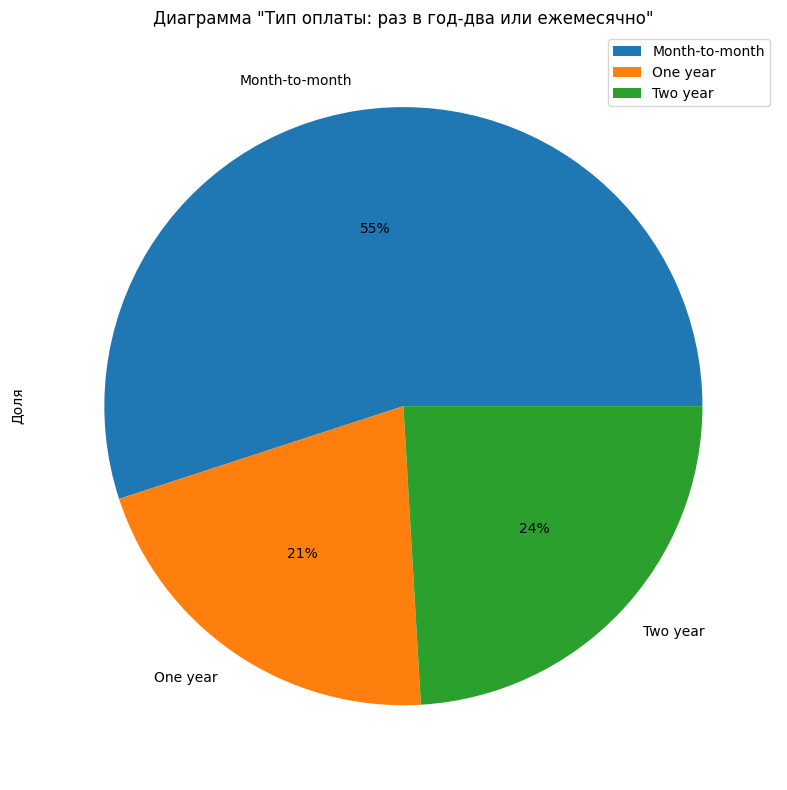

In [17]:
def f_pie(data, col, suptitle):
    fig, (ax1) = plt.subplots(ncols=1)
        
    (
    data
        .pivot_table(index=col,values='CustomerId',aggfunc='count')
        .plot.pie(y='CustomerId', autopct='%1.0f%%', figsize=(8,8), ax=ax1, 
                  label='Доля')
    )
    
    ax1.set_title(suptitle)
    plt.tight_layout()
    plt.show()

f_pie(data=contract_new,
         col='Type',
         suptitle='Диаграмма "Тип оплаты: раз в год-два или ежемесячно"'
)

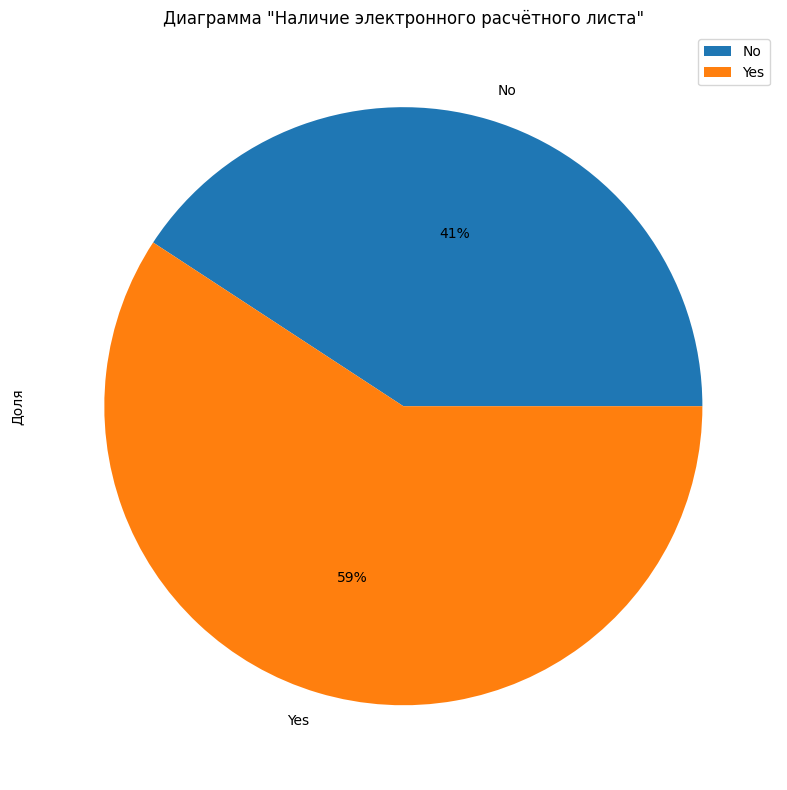

In [18]:
f_pie(data=contract_new,
         col='PaperlessBilling',
         suptitle='Диаграмма "Наличие электронного расчётного листа"'
)

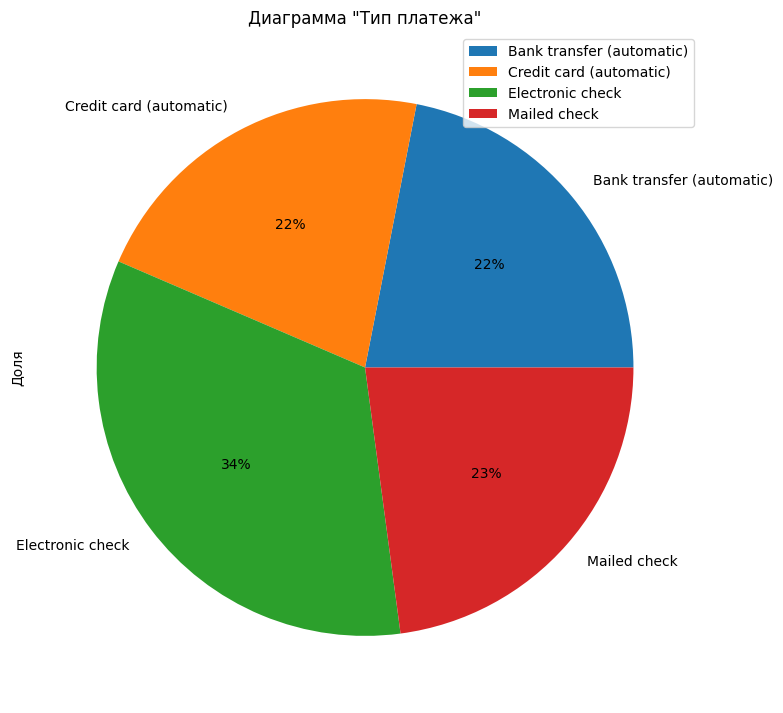

In [19]:
f_pie(data=contract_new,
         col='PaymentMethod',
         suptitle='Диаграмма "Тип платежа"'
)

- 55% клиентов оплачивает услуги помесячно 21% за год и 24% за два года
- 59% клиентов получают счета в электронном виде
- Среди типов платежа преобладает по электронному чеку 34%, остальные распределены равномерно

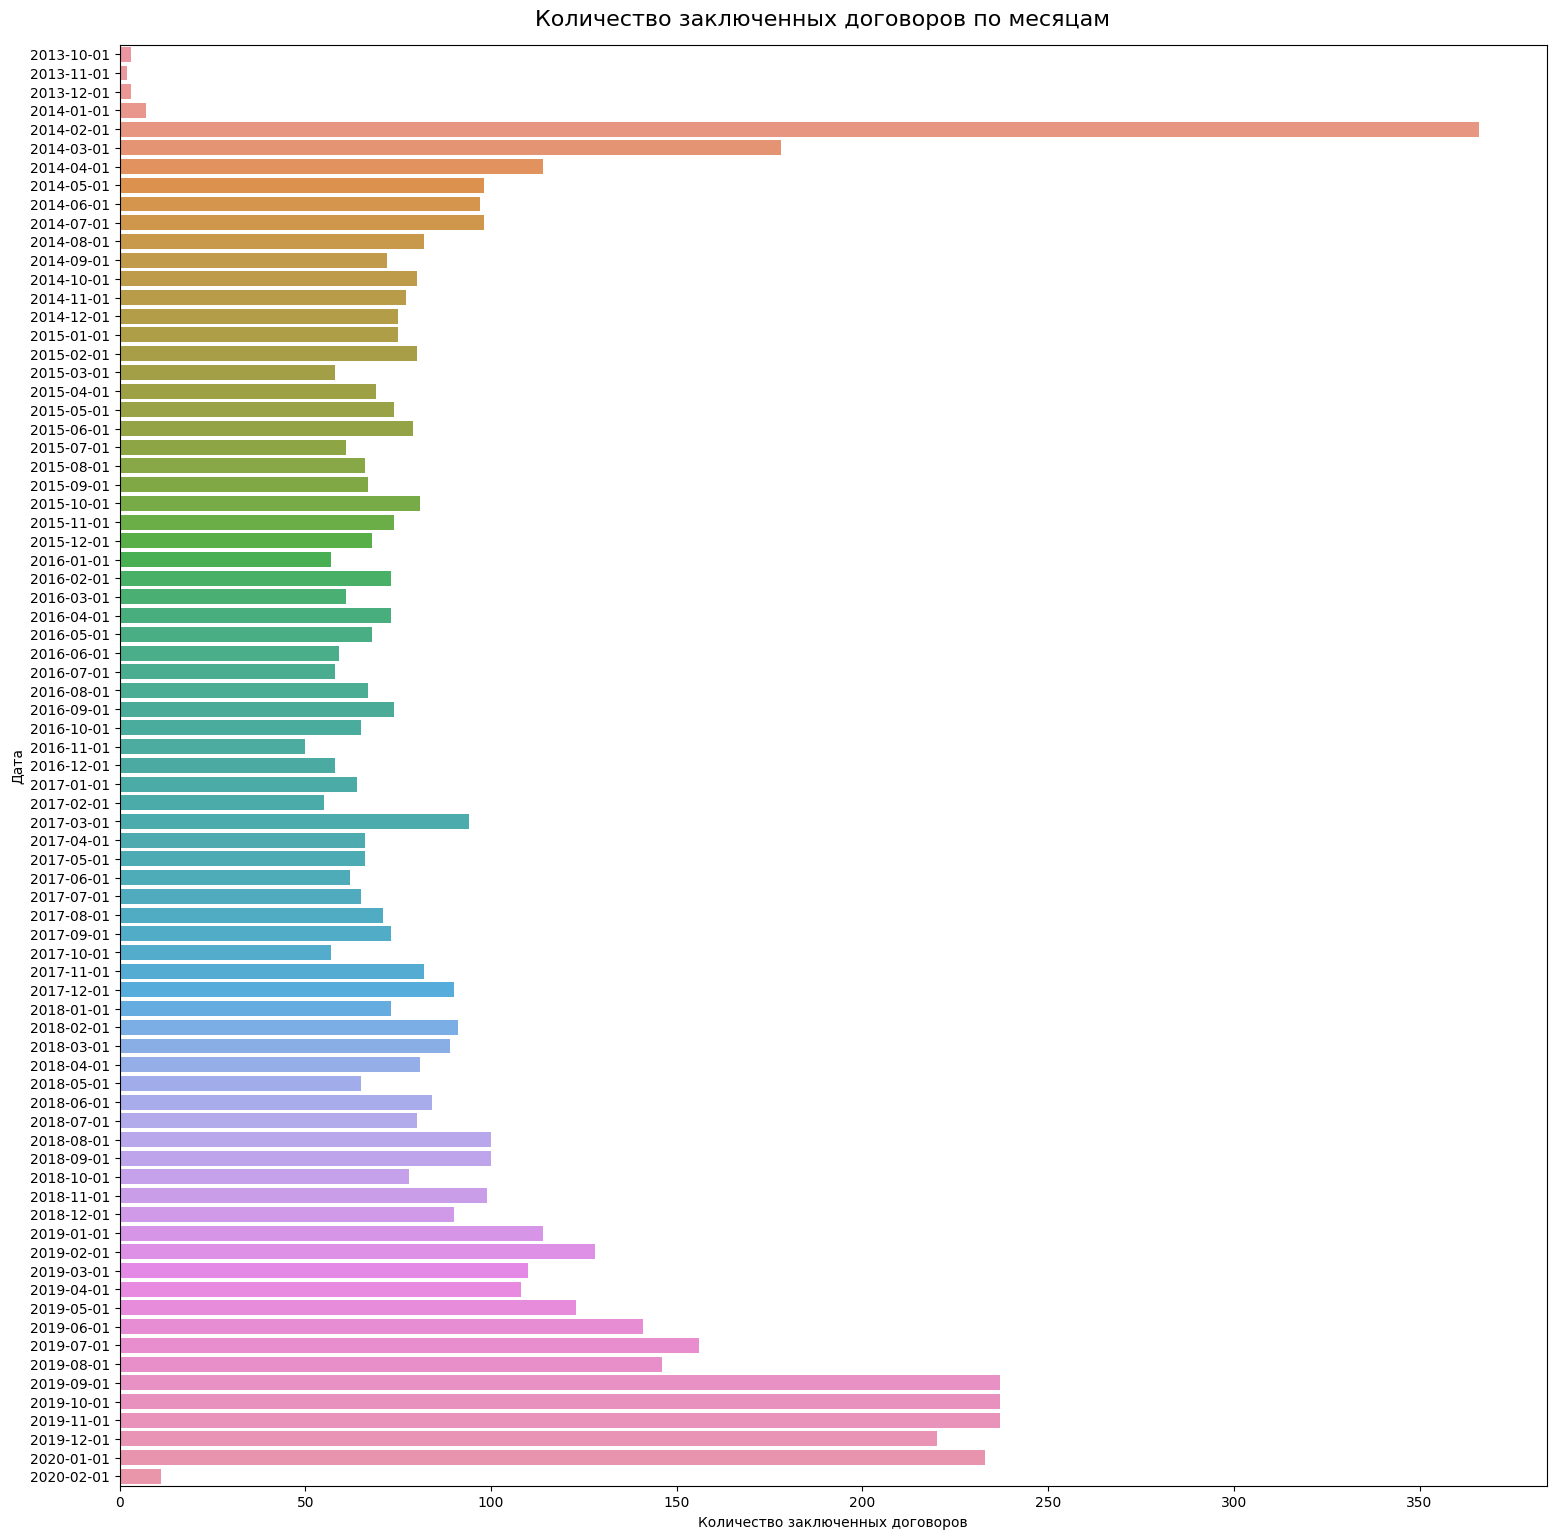

In [20]:
def f_countplot(data, suptitle, xlabel, ylabel):
    fig, (ax1) = plt.subplots(1, 1, figsize=(15, 15))
    fig.tight_layout(h_pad=3)
    fig.suptitle(suptitle, x=0.5, y=1.01, fontsize=16)
    sns.countplot(y=data, ax=ax1)
    ax1.set_xlabel(ylabel)
    ax1.set_ylabel(xlabel)
    
f_countplot(
    data = sorted(contract_new['BeginDate']),
    suptitle = 'Количество заключенных договоров по месяцам',
    xlabel='Дата',
    ylabel='Количество заключенных договоров'
)

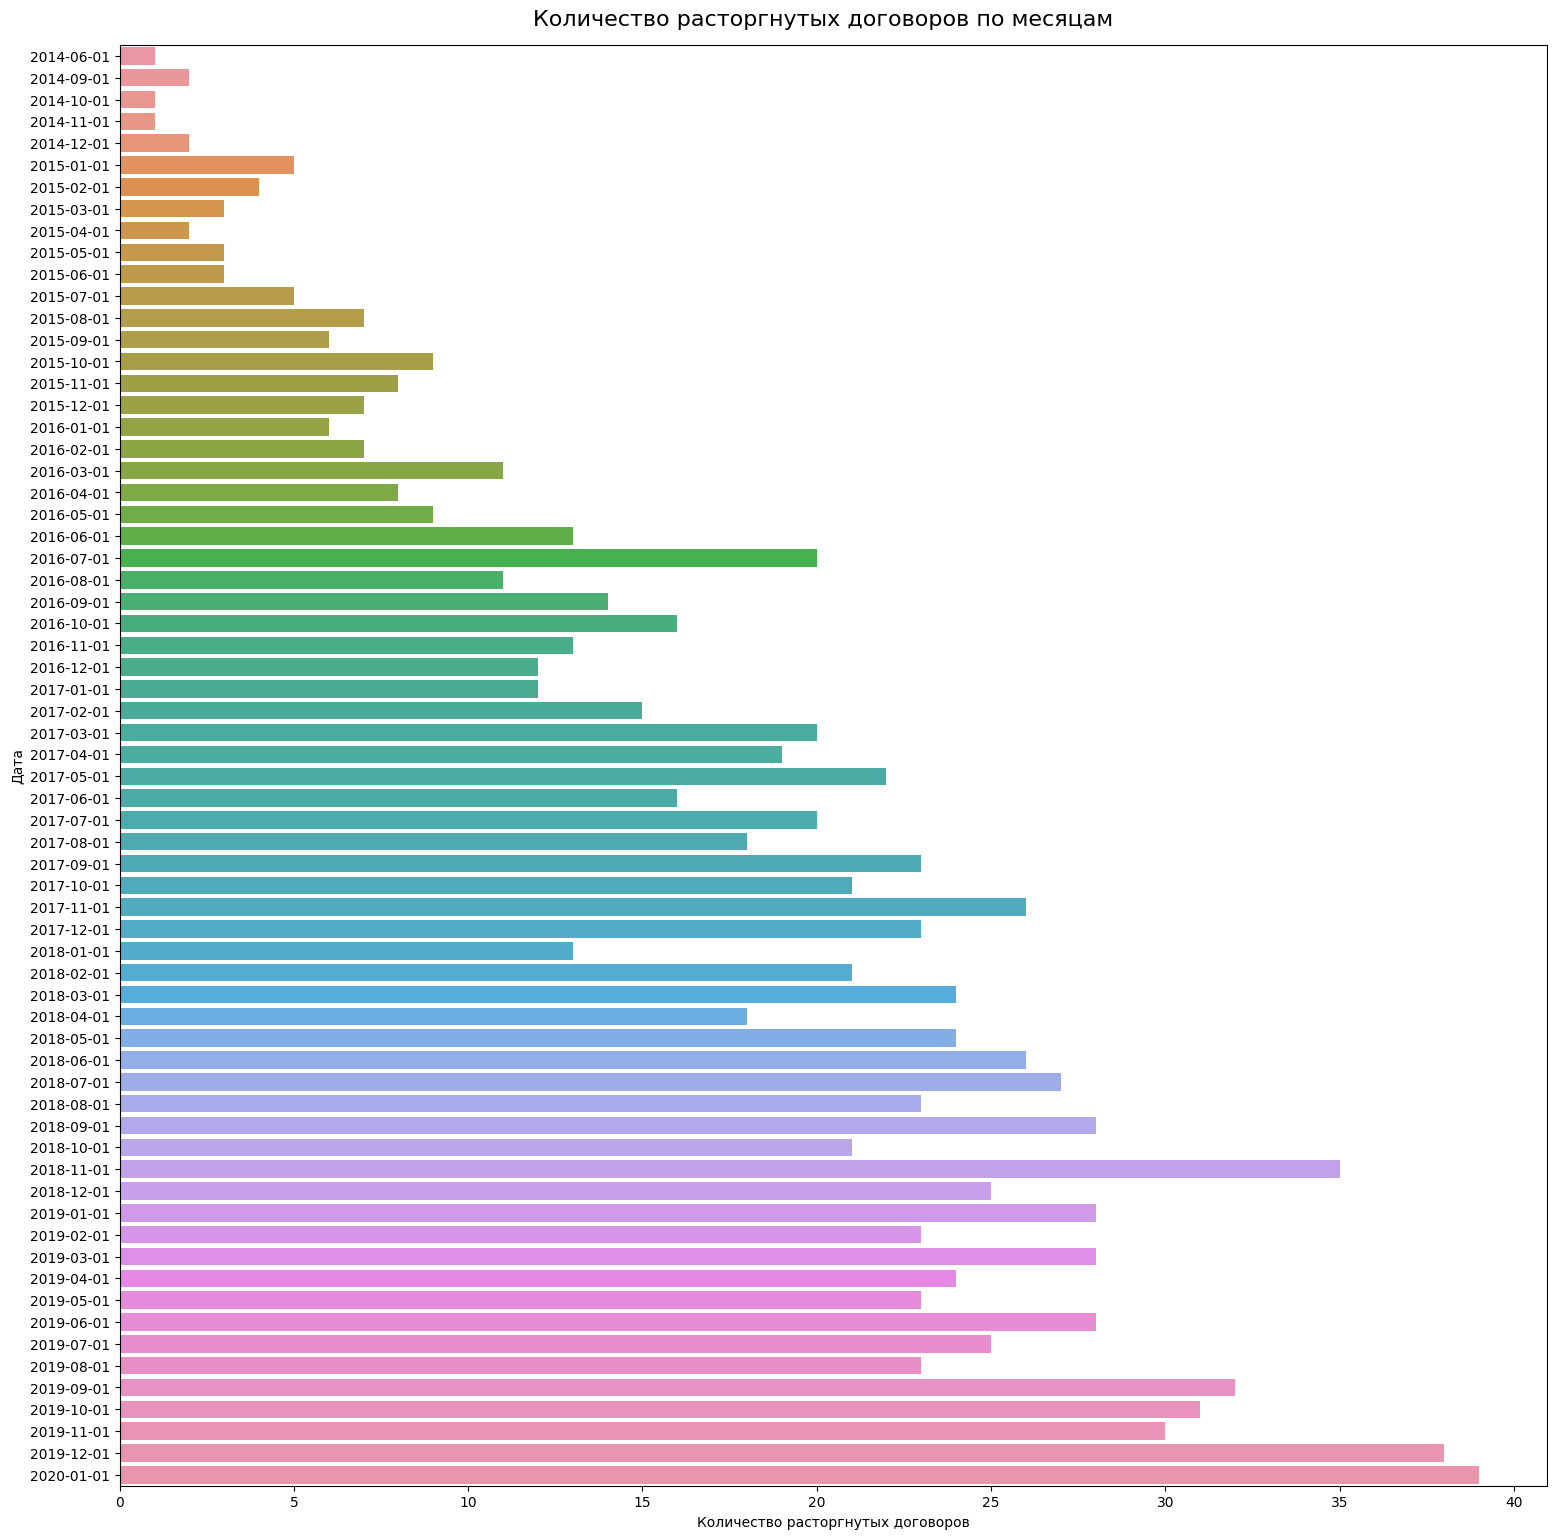

In [21]:
f_countplot(
    data = sorted(contract_new[contract_new['EndDate']!='No']['EndDate']),
    suptitle = 'Количество расторгнутых договоров по месяцам',
    xlabel='Дата',
    ylabel='Количество расторгнутых договоров'
)

При открытии компания работала три месяца в тестовом режиме и количество договоров было незначительно. В январе 2014 года видимо была сделана рекламная компания после чего в феврале 2014 года был резкий всплеск зарегистрированных клиентов. После чего наблюдалась стабилизация объема заключенных договоров. С августа 2018 года наблюдается постепенное увеличение заключенных договоров и в сентябре, октябре, ноябре 2019 года наблюдается их максимум.

Количество рассторгнутых договоров со временем увеличивается и в январе 2020 года достигло максимума в 39 таких договоров.

### Таблица `personal_new`

Проверим уникальные значения в колонках

In [22]:
for col in personal_new.keys():
    print('Уникальные значения в колонке =', col)
    print(personal_new[col].unique(), '\n----------------------------------------')  

Уникальные значения в колонке = CustomerId
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK'] 
----------------------------------------
Уникальные значения в колонке = Gender
['Female' 'Male'] 
----------------------------------------
Уникальные значения в колонке = SeniorCitizen
[0 1] 
----------------------------------------
Уникальные значения в колонке = Partner
['Yes' 'No'] 
----------------------------------------
Уникальные значения в колонке = Dependents
['No' 'Yes'] 
----------------------------------------


Приведем столбцы к единообразию.\
Значения в столбце `SeniorCitizen` заменим: `0` на `No`, `1`  на `Yes`. Тип столбца автоматически изменится на `object`

In [23]:
personal_new['SeniorCitizen'].replace(0, 'No', inplace=True)
personal_new['SeniorCitizen'].replace(1, 'Yes', inplace=True)
personal_new.info()
personal_new

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerId     7043 non-null   object
 1   Gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   object
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: object(5)
memory usage: 275.2+ KB


,CustomerId,Gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,No,Yes,No
1,5575-GNVDE,Male,No,No,No
2,3668-QPYBK,Male,No,No,No
3,7795-CFOCW,Male,No,No,No
4,9237-HQITU,Female,No,No,No
...,...,...,...,...,...
7038,6840-RESVB,Male,No,Yes,Yes
7039,2234-XADUH,Female,No,Yes,Yes
7040,4801-JZAZL,Female,No,Yes,Yes
7041,8361-LTMKD,Male,Yes,Yes,No


Описательная статистика

In [24]:
personal_new.describe(include='object')

,CustomerId,Gender,SeniorCitizen,Partner,Dependents
count,7043,7043,7043,7043,7043
unique,7043,2,2,2,2
top,6627-CFOSN,Male,No,No,No
freq,1,3555,5901,3641,4933


In [25]:
personal_new.describe()

,CustomerId,Gender,SeniorCitizen,Partner,Dependents
count,7043,7043,7043,7043,7043
unique,7043,2,2,2,2
top,6627-CFOSN,Male,No,No,No
freq,1,3555,5901,3641,4933


Замечаний нет. Построим диаграммы данных

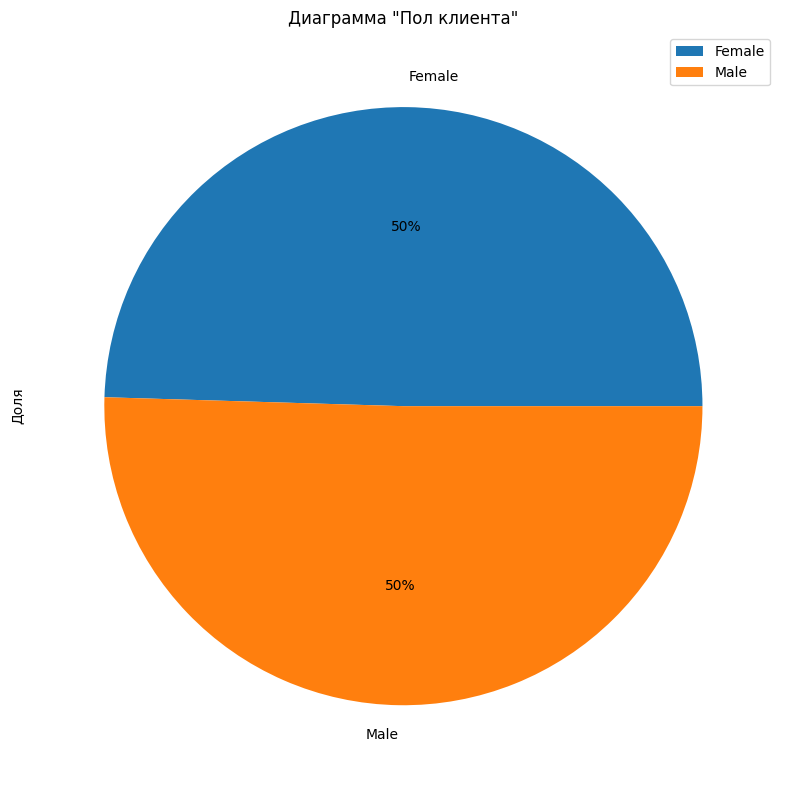

In [26]:
f_pie(data=personal_new,
         col='Gender',
         suptitle='Диаграмма "Пол клиента"'
)

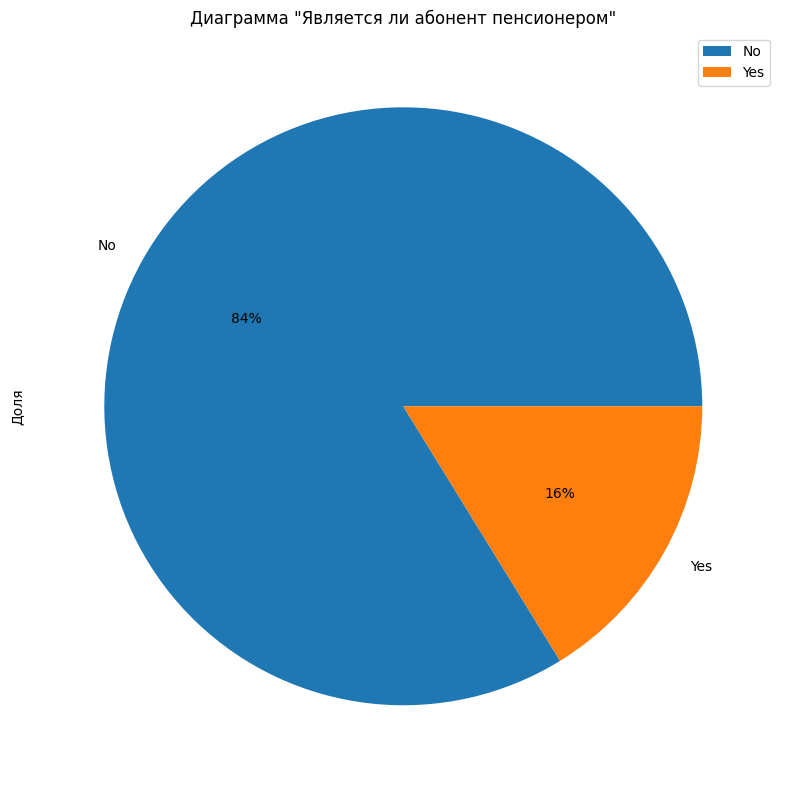

In [27]:
f_pie(data=personal_new,
         col='SeniorCitizen',
         suptitle='Диаграмма "Является ли абонент пенсионером"'
)

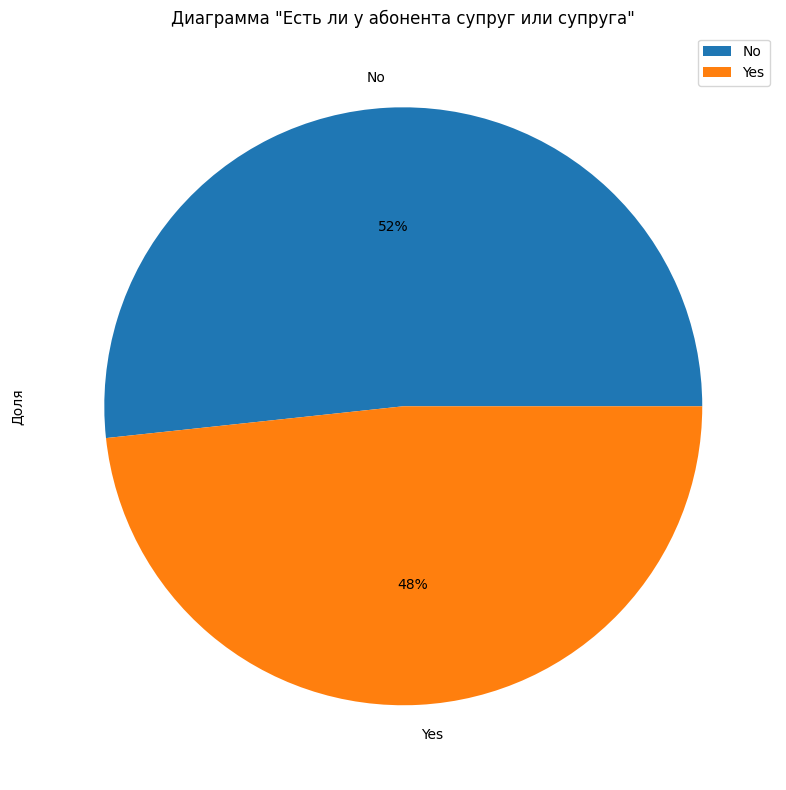

In [28]:
f_pie(data=personal_new,
         col='Partner',
         suptitle='Диаграмма "Есть ли у абонента супруг или супруга"'
)

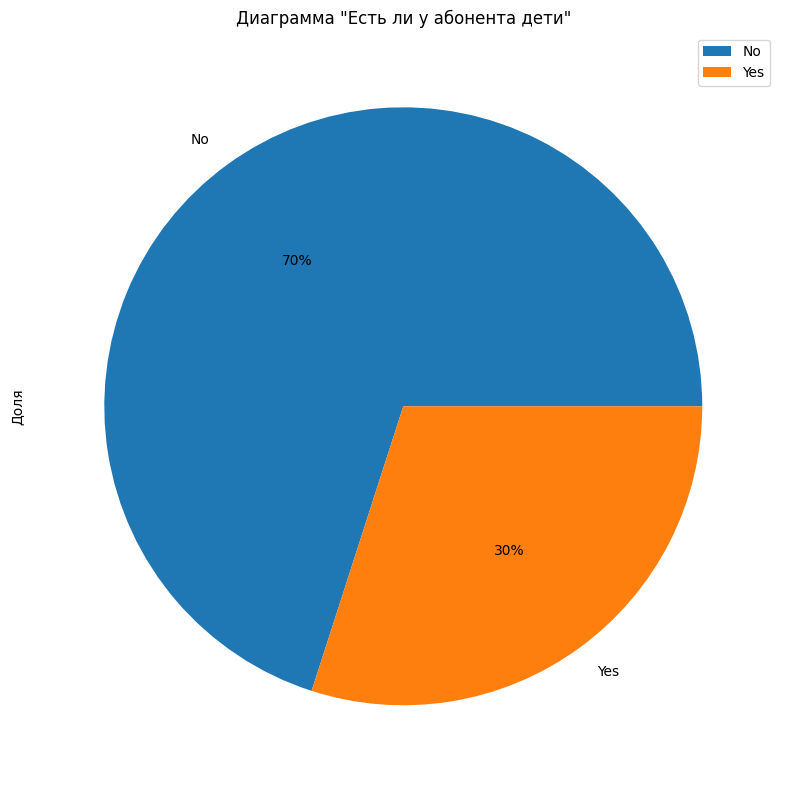

In [29]:
f_pie(data=personal_new,
         col='Dependents',
         suptitle='Диаграмма "Есть ли у абонента дети"'
)

В таблице `personal_new` содержащей 7043 строки следующее распределение:
- 50% клиентов мужчин и 50% клиентов женщин
- 16% что клиент пенсионер, при этом 1 означает Yes, а 0 - No;
- 48% что у клиента есть супруг или супруга
- 30% что у абонента есть дети

### Таблица `internet_new`

Проверим уникальные значения в колонках

In [30]:
for col in internet_new.keys():
    print('Уникальные значения в колонке =', col)
    print(internet_new[col].unique(), '\n----------------------------------------')  

Уникальные значения в колонке = CustomerId
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK'] 
----------------------------------------
Уникальные значения в колонке = InternetService
['DSL' 'Fiber optic'] 
----------------------------------------
Уникальные значения в колонке = OnlineSecurity
['No' 'Yes'] 
----------------------------------------
Уникальные значения в колонке = OnlineBackup
['Yes' 'No'] 
----------------------------------------
Уникальные значения в колонке = DeviceProtection
['No' 'Yes'] 
----------------------------------------
Уникальные значения в колонке = TechSupport
['No' 'Yes'] 
----------------------------------------
Уникальные значения в колонке = StreamingTv
['No' 'Yes'] 
----------------------------------------
Уникальные значения в колонке = StreamingMovies
['No' 'Yes'] 
----------------------------------------


Замечаний нет.

In [31]:
internet_new.describe(include='object')

,CustomerId,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTv,StreamingMovies
count,5517,5517,5517,5517,5517,5517,5517,5517
unique,5517,2,2,2,2,2,2,2
top,6627-CFOSN,Fiber optic,No,No,No,No,No,No
freq,1,3096,3498,3088,3095,3473,2810,2785


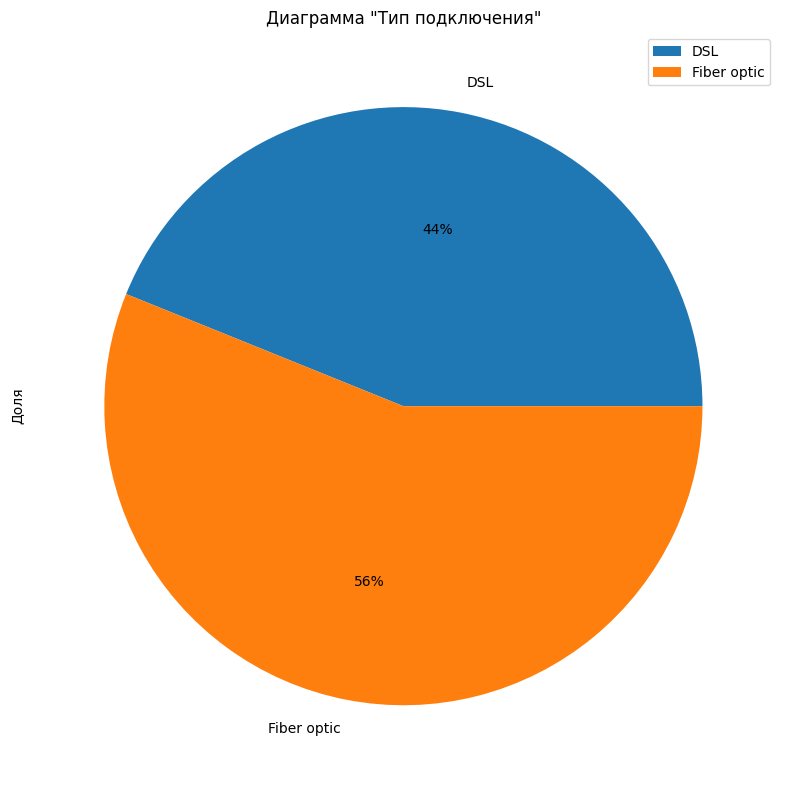

In [32]:
f_pie(data=internet_new,
         col='InternetService',
         suptitle='Диаграмма "Тип подключения"'
)

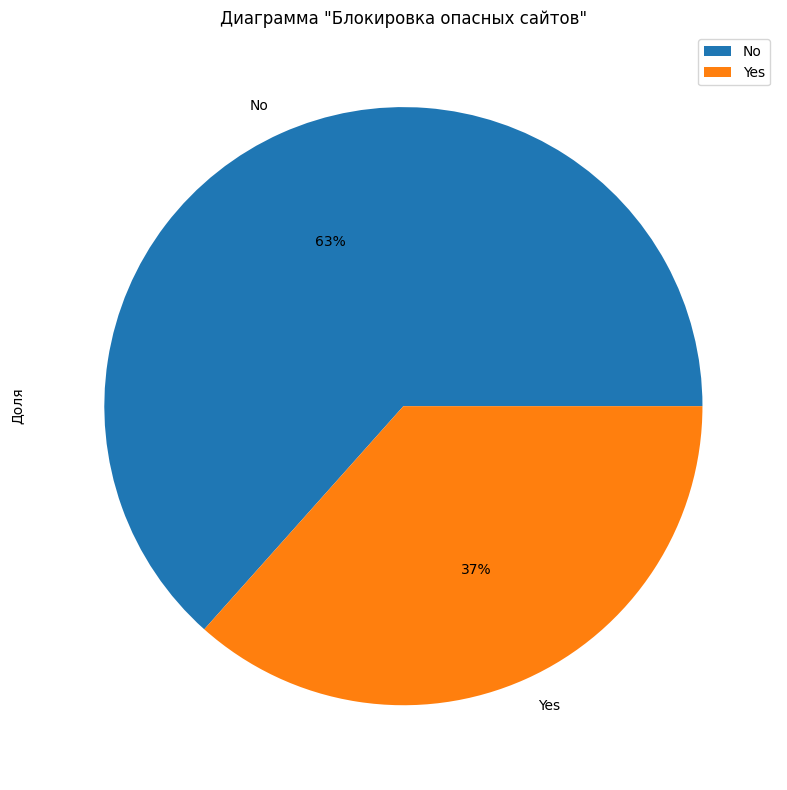

In [33]:
f_pie(data=internet_new,
         col='OnlineSecurity',
         suptitle='Диаграмма "Блокировка опасных сайтов"'
)

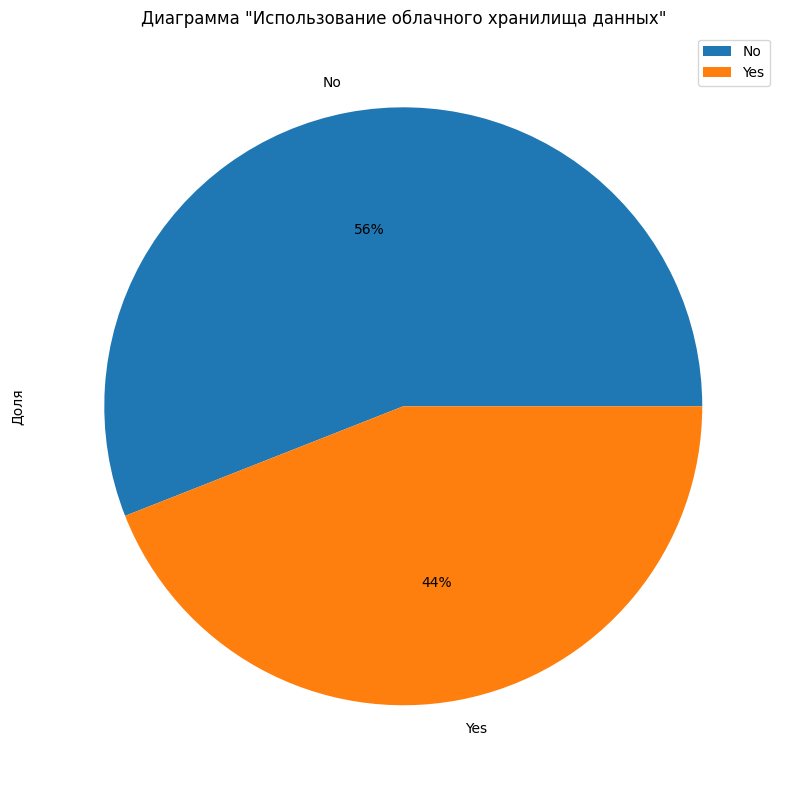

In [34]:
f_pie(data=internet_new,
         col='OnlineBackup',
         suptitle='Диаграмма "Использование облачного хранилища данных"'
)

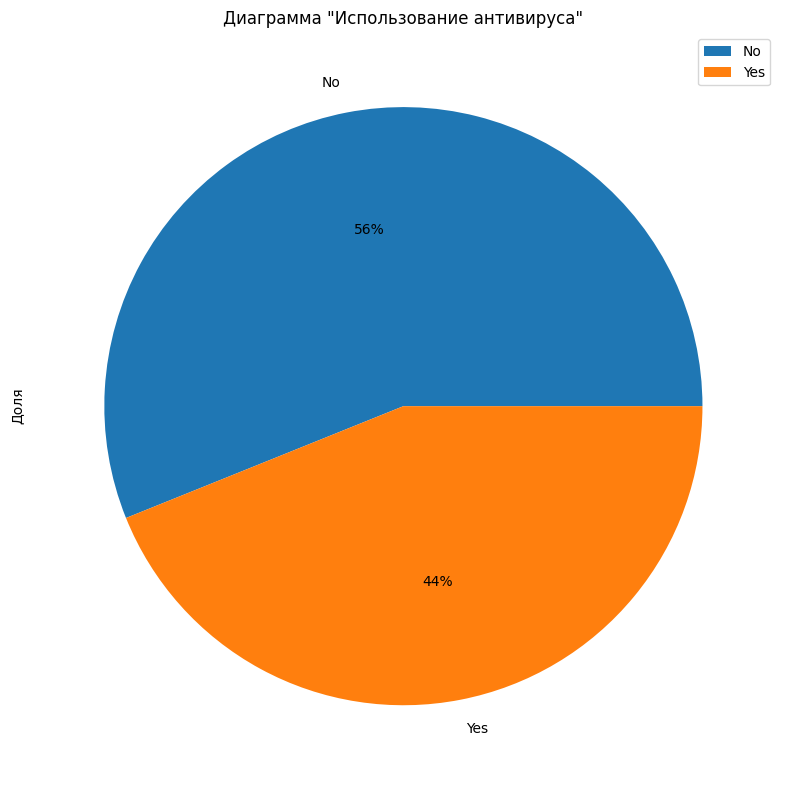

In [35]:
f_pie(data=internet_new,
         col='DeviceProtection',
         suptitle='Диаграмма "Использование антивируса"'
)

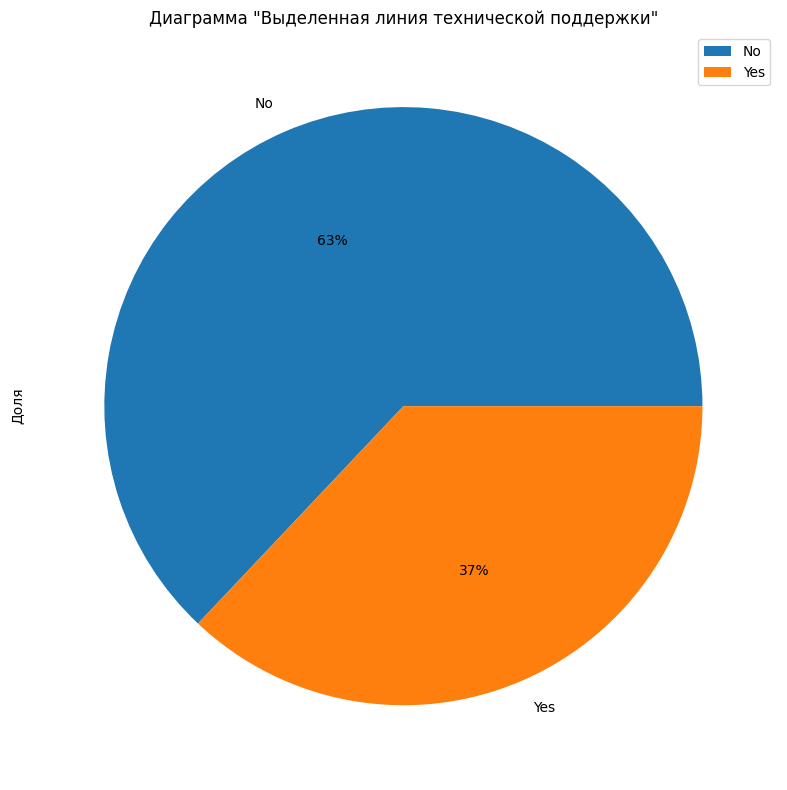

In [36]:
f_pie(data=internet_new,
         col='TechSupport',
         suptitle='Диаграмма "Выделенная линия технической поддержки"'
)

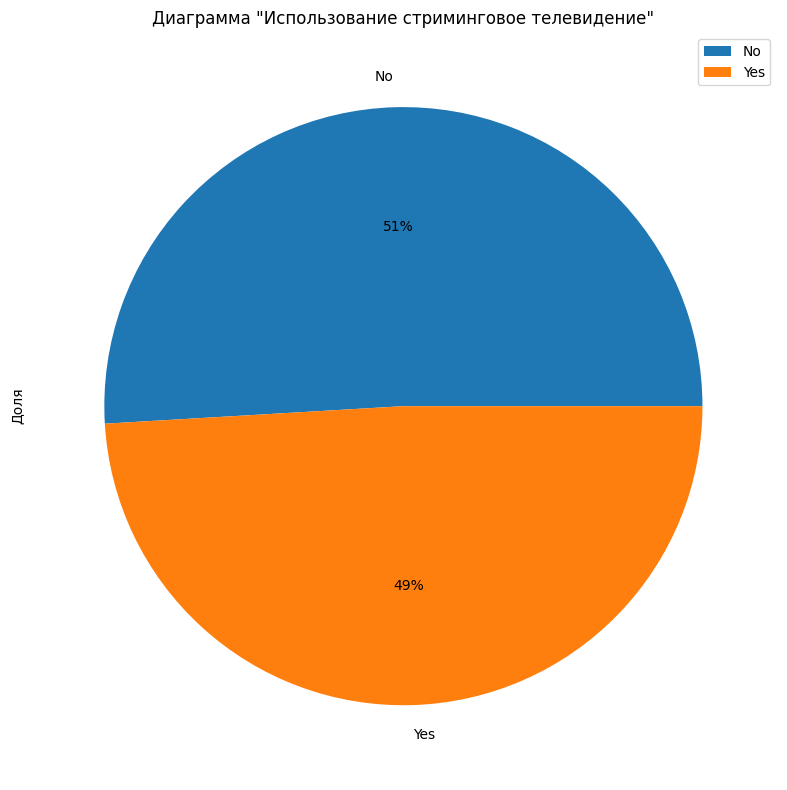

In [37]:
f_pie(data=internet_new,
         col='StreamingTv',
         suptitle='Диаграмма "Использование стриминговое телевидение"'
)

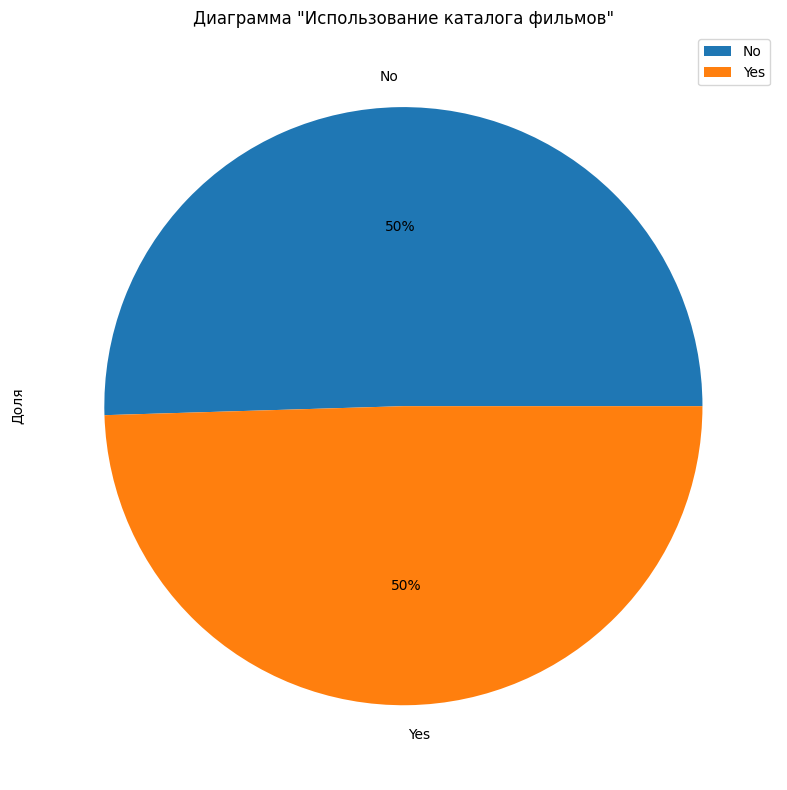

In [38]:
f_pie(data=internet_new,
         col='StreamingMovies',
         suptitle='Диаграмма "Использование каталога фильмов"'
)

В таблице `internet_new` содержащей 5517 строки следующее распределение:
- 56% что подключение по оптоволокну
- 37% что клиент использует блокировку опасных сайтов
- 44% что клиент использует облачное хранилище данных
- 44% что клиент использует антивирус
- 37% что клиент использует выделенную линию технической поддержки
- 49% что клиент использует стриминговое телевидение
- 50% что клиент использует каталог фильмов

### Таблица `phone_new`

Проверим уникальные значения в колонках

In [39]:
for col in phone_new.keys():
    print('Уникальные значения в колонке =', col)
    print(phone_new[col].unique(), '\n----------------------------------------') 

Уникальные значения в колонке = CustomerId
['5575-GNVDE' '3668-QPYBK' '9237-HQITU' ... '2234-XADUH' '8361-LTMKD'
 '3186-AJIEK'] 
----------------------------------------
Уникальные значения в колонке = MultipleLines
['No' 'Yes'] 
----------------------------------------


Замечаний нет.

In [40]:
phone_new.describe(include='object')

,CustomerId,MultipleLines
count,6361,6361
unique,6361,2
top,6627-CFOSN,No
freq,1,3390


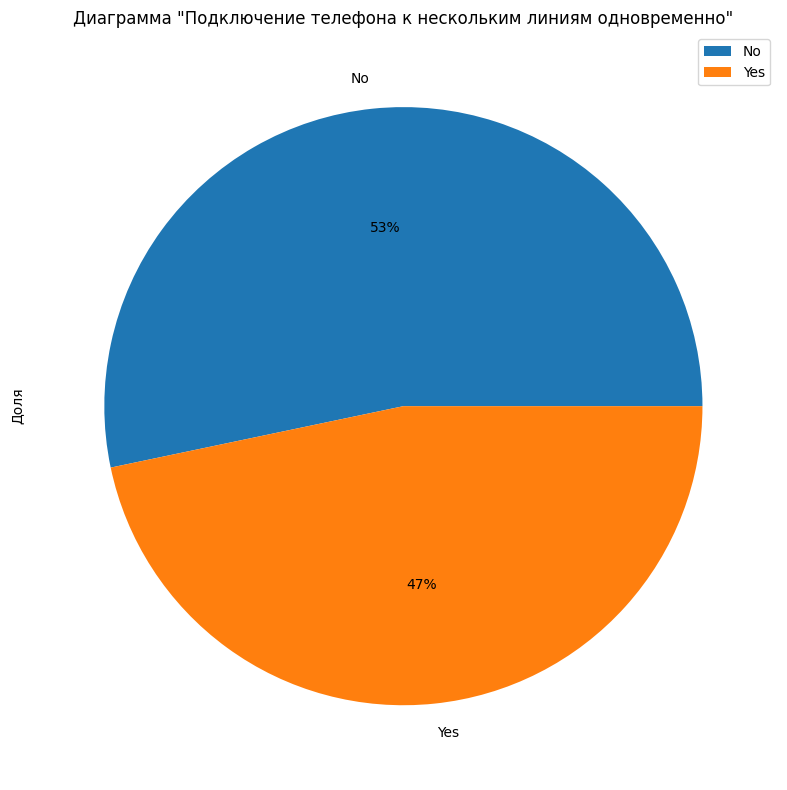

In [41]:
f_pie(data=phone_new,
         col='MultipleLines',
         suptitle='Диаграмма "Подключение телефона к нескольким линиям одновременно"'
)

В таблице `phone_new` содержащей 6361 строк следующее распределение:
- 47% что подключение осуществлено к нескольким линиям телефонов

#### Выводы по предобработке и анализу данных

Все названия столбцов в таблицах приведены к виду Pascal, что допустимо. В таблице contract_new в столбце TotalCharges (суммарные затраты клиента) обнаружены пропуски данных. Их решено заполнить нулями и привести столбец к типу float, так как это новые клиенты, еще не совершившие оплату за месяц, или их траты пока неизвестны.

Таблица contract_new

1. Месячная оплата (MonthlyCharges):
* Распределение значений дискретно и бимодально. Максимум клиентов имеет траты 20, затем количество снижается, стабилизируясь после медианного значения 70,35. Выбросов нет. Дискретность, вероятно, обусловлена тарифными планами.
2. Общие расходы (TotalCharges):
* Распределение нормальное. Максимум клиентов с тратами около нуля, затем постепенное снижение. Медианное значение — 1343,35. В данных есть выбросы — клиенты с большими расходами.
3. Оплата услуг:
* 55% клиентов оплачивают помесячно, 21% — за год, 24% — за два года.
* 59% получают счета в электронном виде.
* Преобладает оплата по электронному чеку (34%). Остальные способы распределены равномерно.
4. Динамика договоров:
* Компания работала три месяца в тестовом режиме, количество договоров было невелико. В январе 2014 года была рекламная кампания, после чего в феврале 2014 года наблюдался резкий рост новых клиентов. Затем количество договоров стабилизировалось. С августа 2018 года началось постепенное увеличение, достигнув максимума в сентябре, октябре и ноябре 2019 года.
* Количество расторгнутых договоров растет, достигнув максимума (39) в январе 2020 года.

Таблица personal_new

В таблице 7043 строки:

* 50% мужчин, 50% женщин;
* 16% пенсионеров (1 — да, 0 — нет);
* 48% имеют супруга или супругу;
* 30% имеют детей.

Таблица internet_new

В таблице 5517 строк:

* 56% подключены по оптоволокну;
* 37% используют блокировку опасных сайтов;
* 44% используют облачное хранилище данных;
* 44% используют антивирус;
* 37% имеют выделенную линию техподдержки;
* 49% используют стриминговое телевидение;
* 50% используют каталог фильмов.

Таблица phone_new

В таблице 6361 строка:

* 47% подключены к нескольким линиям телефонов.

Предобработка и анализ данных позволяют перейти к следующему этапу.

## Объединение данных

Проведем объединение данных по столбцу `CustomerId` с проверкой объединения по индикатору

In [42]:
#df = contract_new.merge(personal_new, on='CustomerId', how='outer', indicator='source')
df = contract_new.merge(personal_new, on='CustomerId', how='left', indicator='source')
print(df['source'].unique())
df.drop('source', axis=1, inplace=True)

['both']
Categories (1, object): ['both']


In [43]:
#df = df.merge(internet_new, on='CustomerId', how='outer', indicator='source')
df = df.merge(internet_new, on='CustomerId', how='left', indicator='source')
print(df['source'].unique())
df.drop('source', axis=1, inplace=True)

['both', 'left_only']
Categories (2, object): ['both', 'left_only']


In [44]:
#df = df.merge(phone_new, on='CustomerId', how='outer', indicator='source')
df = df.merge(phone_new, on='CustomerId', how='left', indicator='source')
print(df['source'].unique())
df.drop('source', axis=1, inplace=True)

['left_only', 'both']
Categories (2, object): ['left_only', 'both']


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerId        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   float64
 8   Gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   object 
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   5517 non-null   object 
 13  OnlineSecurity    5517 non-null   object 
 14  OnlineBackup      5517 non-null   object 
 15  DeviceProtection  5517 non-null   object 
 16  TechSupport       5517 non-null   object 


**Вывод:**
Объединение данных прошло успешно, проведем предобработку данных, проведем исследовательский анализ данных

## Исследовательский анализ и предобработка данных объединённого датафрейма

### Проведем обработку данных

При объединении таблиц образовались пропуски так как не все клиенты используют оба пакета услуг, а заказчик не предоставил полных сведений по всем клиентам. Логично заполнить все пропуски на признак, что клиент не использует данный пакет услуг `No`. Но в данном случае принятое решение может оказаться неверным, так как признак
- `Yes` может указывать на то что услуга подключена в данный момент
- `No` на то что услуга была подключена, но в настоящий момент неактивна
- наличие пропуска в данных может указывать на то, что услуга вообще не подключалась

Тем кто использует только телефон дополнительные услуги  по интернету не нужны, а тем кто неиспользует телефон дополнительная функция по мультилинии не будет востребована. В этом случае простая замена пропусков на `unknown` может оказаться недостаточной. 

Сделаем замену пропусков с привязкой к типу основного пакета:
- `Т` означает что данные отсутствуют и пакет используется с телефонией
- `I` означает, что данные отсутствуют и пакет используется с интернетом

In [46]:
i = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTv', 'StreamingMovies']
t = ['MultipleLines']
df[t] = df[t].fillna('T')
df[i] = df[i].fillna('I')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerId        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   float64
 8   Gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   object 
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   7043 non-null   object 
 13  OnlineSecurity    7043 non-null   object 
 14  OnlineBackup      7043 non-null   object 
 15  DeviceProtection  7043 non-null   object 
 16  TechSupport       7043 non-null   object 


Замена пропусков произведена успешно, пропуски в данных отсутствуют. \
Создадим целевой столбец из `EndDate`. 

Наша цель найти клиентов которые разорвут договор, а это клиенты у которых в столбце стоит дата окончания договора.
Присвоим таким клиентам значение `1` остальным `0`

In [47]:
def f_target(row):
    if row['EndDate'] == 'No':
        return 0
    return 1

df['Target'] = df.apply(f_target, axis=1)
df[9:16]

,CustomerId,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Gender,SeniorCitizen,...,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTv,StreamingMovies,MultipleLines,Target
9,6388-TABGU,2014-12-01,2017-05-01,One year,No,Bank transfer (automatic),56.15,1628.35,Male,No,...,Yes,DSL,Yes,Yes,No,No,No,No,No,1
10,9763-GRSKD,2019-01-01,No,Month-to-month,Yes,Mailed check,49.95,649.35,Male,No,...,Yes,DSL,Yes,No,No,No,No,No,No,0
11,7469-LKBCI,2018-10-01,No,Two year,No,Credit card (automatic),18.95,312.30,Male,No,...,No,I,I,I,I,I,I,I,No,0
12,8091-TTVAX,2015-04-01,No,One year,No,Credit card (automatic),100.35,6111.31,Male,No,...,No,Fiber optic,No,No,Yes,No,Yes,Yes,Yes,0
13,0280-XJGEX,2015-09-01,No,Month-to-month,Yes,Bank transfer (automatic),103.70,5496.10,Male,No,...,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,0
14,5129-JLPIS,2018-01-01,No,Month-to-month,Yes,Electronic check,105.50,2637.50,Male,No,...,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,No,0
15,3655-SNQYZ,2014-05-01,2016-03-01,Two year,No,Credit card (automatic),113.25,2491.50,Female,No,...,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Yes,1


Визуальный контроль указывает, что целевой столбец `Target` создан правильно.\
Заполним значения `No` в столбце `EndDate` актуальную дату сбора данных 1 февраля 2020 года = 2020-02-01, приведем тип столбцов `BeginDate`, `EndDate` к datetime, введем новый показатель `DurationContract` - длительность действия договора в днях

In [48]:
df['EndDate'].replace('No', '2020-02-01', inplace=True)
df['BeginDate'] = pd.to_datetime(df['BeginDate'])
df['EndDate'] = pd.to_datetime(df['EndDate'])
df['DurationContract'] = (df['EndDate'] - df['BeginDate']).dt.days
display(df.head())
df.info()

,CustomerId,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Gender,SeniorCitizen,...,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTv,StreamingMovies,MultipleLines,Target,DurationContract
0,7590-VHVEG,2020-01-01,2020-02-01,Month-to-month,Yes,Electronic check,29.85,31.04,Female,No,...,DSL,No,Yes,No,No,No,No,T,0,31
1,5575-GNVDE,2017-04-01,2020-02-01,One year,No,Mailed check,56.95,2071.84,Male,No,...,DSL,Yes,No,Yes,No,No,No,No,0,1036
2,3668-QPYBK,2019-10-01,2020-02-01,Month-to-month,Yes,Mailed check,53.85,226.17,Male,No,...,DSL,Yes,Yes,No,No,No,No,No,0,123
3,7795-CFOCW,2016-05-01,2020-02-01,One year,No,Bank transfer (automatic),42.30,1960.60,Male,No,...,DSL,Yes,No,Yes,Yes,No,No,T,0,1371
4,9237-HQITU,2019-09-01,2020-02-01,Month-to-month,Yes,Electronic check,70.70,353.50,Female,No,...,Fiber optic,No,No,No,No,No,No,No,0,153


<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerId        7043 non-null   object        
 1   BeginDate         7043 non-null   datetime64[ns]
 2   EndDate           7043 non-null   datetime64[ns]
 3   Type              7043 non-null   object        
 4   PaperlessBilling  7043 non-null   object        
 5   PaymentMethod     7043 non-null   object        
 6   MonthlyCharges    7043 non-null   float64       
 7   TotalCharges      7043 non-null   float64       
 8   Gender            7043 non-null   object        
 9   SeniorCitizen     7043 non-null   object        
 10  Partner           7043 non-null   object        
 11  Dependents        7043 non-null   object        
 12  InternetService   7043 non-null   object        
 13  OnlineSecurity    7043 non-null   object        
 14  OnlineBackup      7043 n

Проведем визуализацию признаков

In [49]:
df.describe()

,MonthlyCharges,TotalCharges,Target,DurationContract
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,64.761692,2115.312885,0.156325,898.555729
std,30.090047,2112.742814,0.363189,683.130510
min,18.250000,0.000000,0.000000,0.000000
25%,35.500000,436.750000,0.000000,276.000000
50%,70.350000,1343.350000,0.000000,761.000000
75%,89.850000,3236.690000,0.000000,1461.000000
max,118.750000,9221.380000,1.000000,2314.000000


In [50]:
def show_hist_boxplot(df: pd.Series,
                      bins: int = 100,
                      hist_title: str = None,
                      hist_xlabel: str = None,
                      hist_ylabel: str = None,
                      bp_title: str = None,
                      bp_xlabel: str = None,
                      bp_ylabel: str = None) -> None:

    """
    Отображает графики hist и boxplot для переданных данных
    """

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 10), gridspec_kw={'height_ratios': [3, 1]})

    axes[0].hist(x=df, bins=bins)
    axes[0].set_title(hist_title)
    axes[0].set_xlabel(hist_xlabel)
    axes[0].set_ylabel(hist_ylabel)

    axes[1].boxplot(df, vert=False)
    axes[1].set_title(bp_title)
    axes[1].set_xlabel(bp_xlabel)
    axes[1].set_ylabel(bp_ylabel)

    plt.show()

In [51]:
payment_type_df = df.groupby('Type')['Target'].count()
payment_type_df

Type
Month-to-month    3875
One year          1473
Two year          1695
Name: Target, dtype: int64

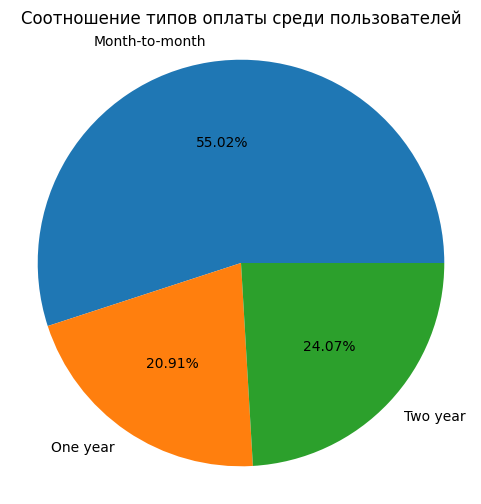

In [52]:
payment_type_df.plot(title='Соотношение типов оплаты среди пользователей', kind='pie', autopct=lambda x: f'{x:.2f}%', ylabel='', radius=1.1, grid=True, figsize=(15, 6));

In [53]:
paperless_billing_df = df.groupby('PaperlessBilling')['Target'].count()
paperless_billing_df

PaperlessBilling
No     2872
Yes    4171
Name: Target, dtype: int64

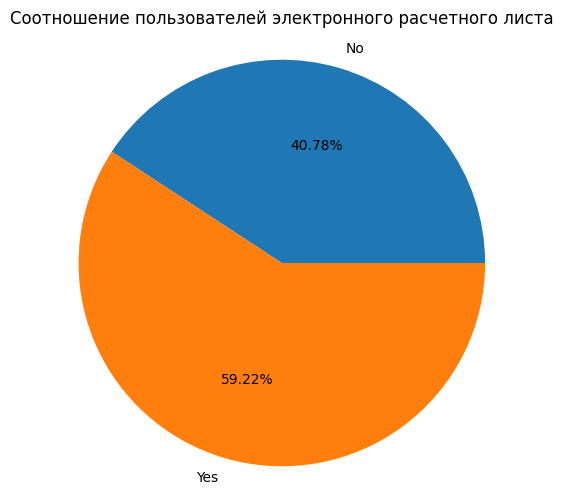

In [54]:
paperless_billing_df.plot(title='Соотношение пользователей электронного расчетного листа', kind='pie', autopct=lambda x: f'{x:.2f}%', ylabel='', radius=1.1, grid=True, figsize=(15, 6));

59% рассматриваемых абонентов компании пользуют электронным расчетным листом

In [55]:
payment_method_df = df.groupby('PaymentMethod')['Target'].count()
payment_method_df

PaymentMethod
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Electronic check             2365
Mailed check                 1612
Name: Target, dtype: int64

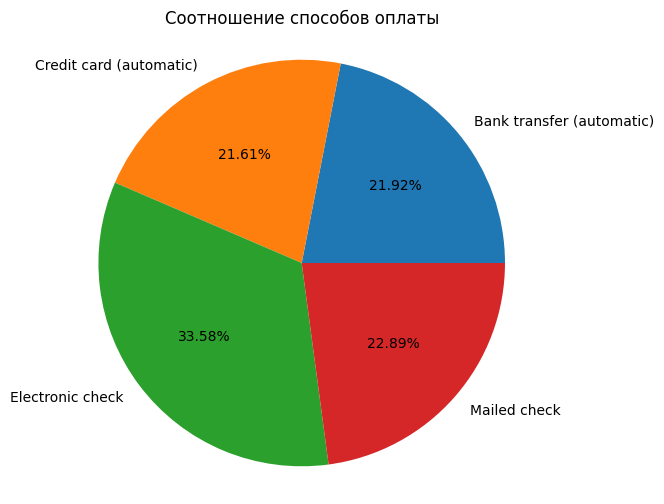

In [56]:
payment_method_df.plot(title='Соотношение способов оплаты', kind='pie', autopct=lambda x: f'{x:.2f}%', ylabel='', radius=1.1, grid=True, figsize=(15, 6));

Электронные чеки популярны среди пользователей. На втором месте находятся чеки по почте.

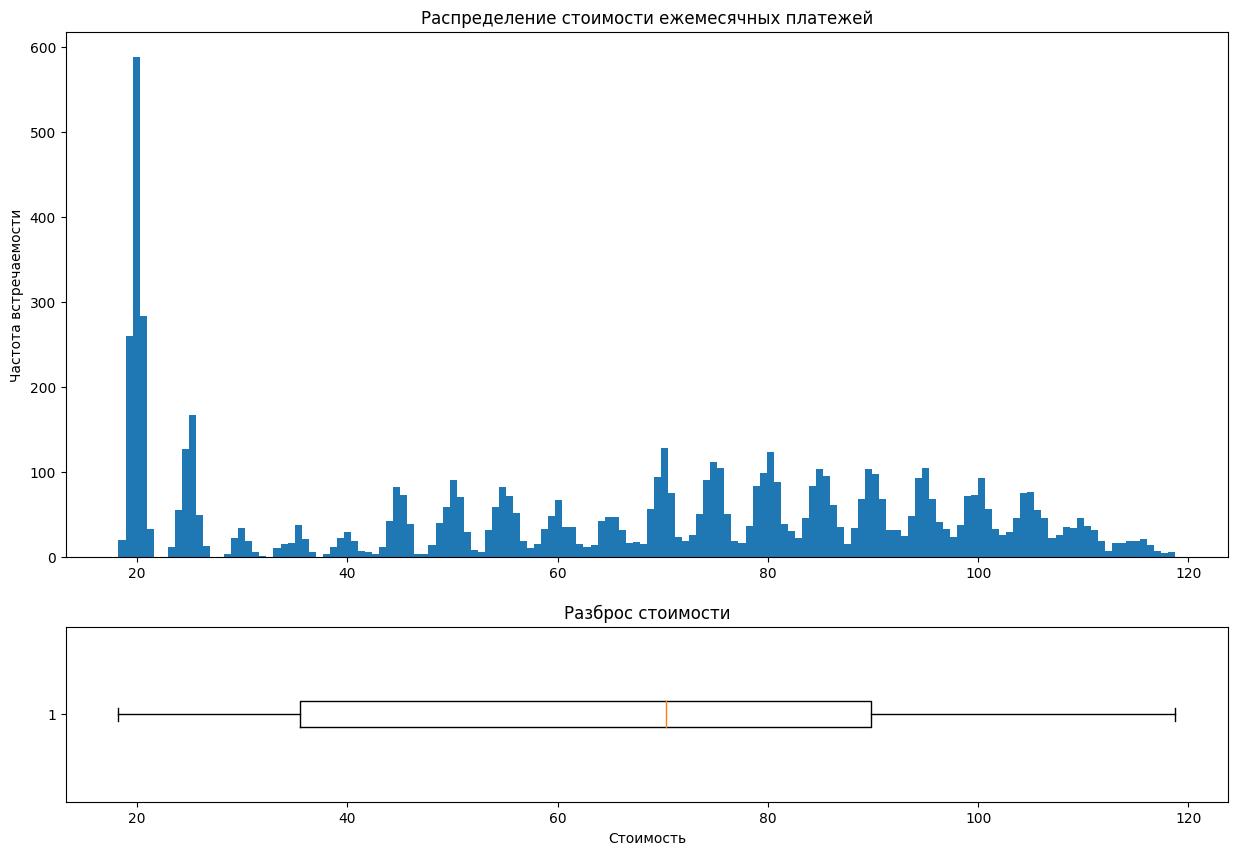

In [57]:
show_hist_boxplot(df.MonthlyCharges, bins=150,
                  hist_title='Распределение стоимости ежемесячных платежей',
                  hist_ylabel='Частота встречаемости',
                  bp_title='Разброс стоимости', bp_xlabel='Стоимость')

В значениях данного признака нет выбросов. Также видим пик популярности самого дешевого пакета услуг на уровне 20.

In [58]:
internet_service_df = df.groupby('InternetService')['Target'].count()
internet_service_df

InternetService
DSL            2421
Fiber optic    3096
I              1526
Name: Target, dtype: int64

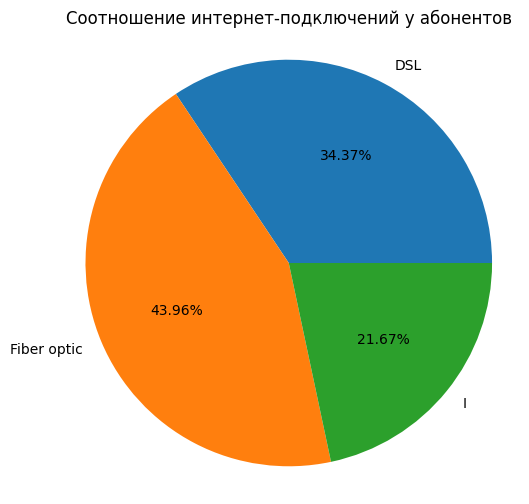

In [59]:
internet_service_df.plot(title='Соотношение интернет-подключений у абонентов', kind='pie', autopct=lambda x: f'{x:.2f}%', ylabel='', radius=1.1, grid=True, figsize=(15, 6));

Большинство абонентов пользуются оптоволокном при подключении к интернету.

In [60]:
gender_df = df.groupby('Gender')['Target'].count()
gender_df

Gender
Female    3488
Male      3555
Name: Target, dtype: int64

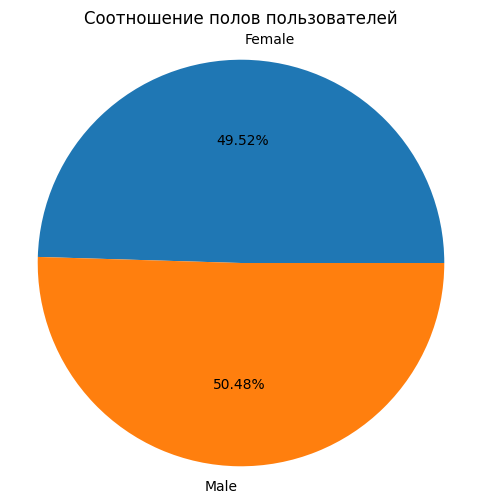

In [61]:
gender_df.plot(title='Соотношение полов пользователей', kind='pie', autopct=lambda x: f'{x:.2f}%', ylabel='', radius=1.1, grid=True, figsize=(15, 6));

Абоненты в равных количествах со стороны пола

In [62]:
senior_citizen_df = df.groupby('SeniorCitizen')['Target'].count()
senior_citizen_df

SeniorCitizen
No     5901
Yes    1142
Name: Target, dtype: int64

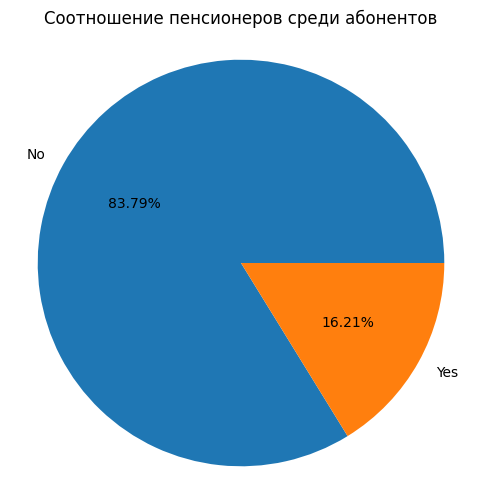

In [63]:
senior_citizen_df.plot(title='Соотношение пенсионеров среди абонентов', kind='pie', autopct=lambda x: f'{x:.2f}%', ylabel='', radius=1.1, grid=True, figsize=(15, 6));

Подавляющее число пользователей компании не являются пенсионерами.

In [64]:
partner_df = df.groupby('Partner')['Target'].count()
partner_df

Partner
No     3641
Yes    3402
Name: Target, dtype: int64

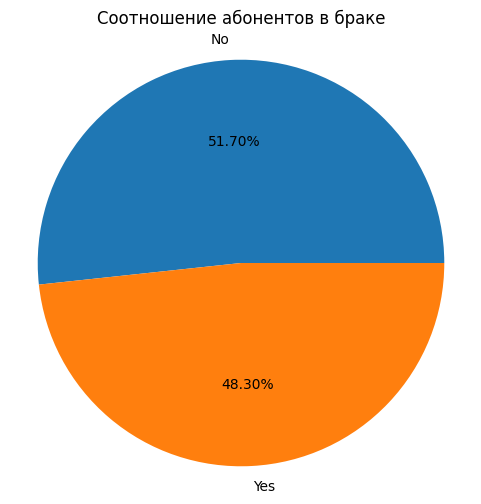

In [65]:
partner_df.plot(title='Соотношение абонентов в браке', kind='pie', autopct=lambda x: f'{x:.2f}%', ylabel='', radius=1.1, grid=True, figsize=(15, 6));

соотношение практически равно

In [66]:
dependents_df = df.groupby('Dependents')['Target'].count()
dependents_df

Dependents
No     4933
Yes    2110
Name: Target, dtype: int64

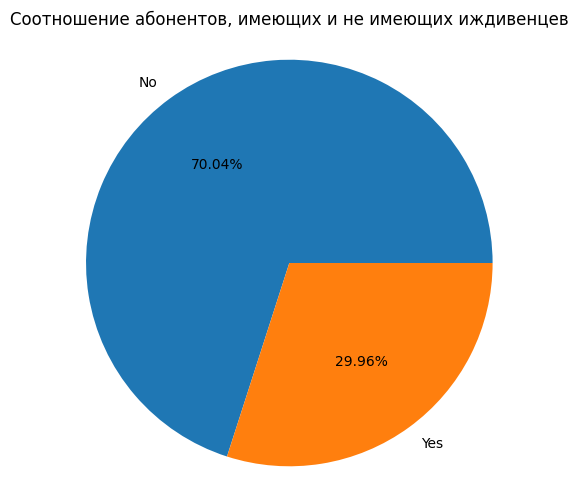

In [67]:
dependents_df.plot(title='Соотношение абонентов, имеющих и не имеющих иждивенцев', kind='pie', autopct=lambda x: f'{x:.2f}%', ylabel='', radius=1.1, grid=True, figsize=(15, 6));

30% клиентов компании не имеют иждивенцевm̀

In [68]:
multiple_lines_df = df.groupby('MultipleLines')['Target'].count()
multiple_lines_df

MultipleLines
No     3390
T       682
Yes    2971
Name: Target, dtype: int64

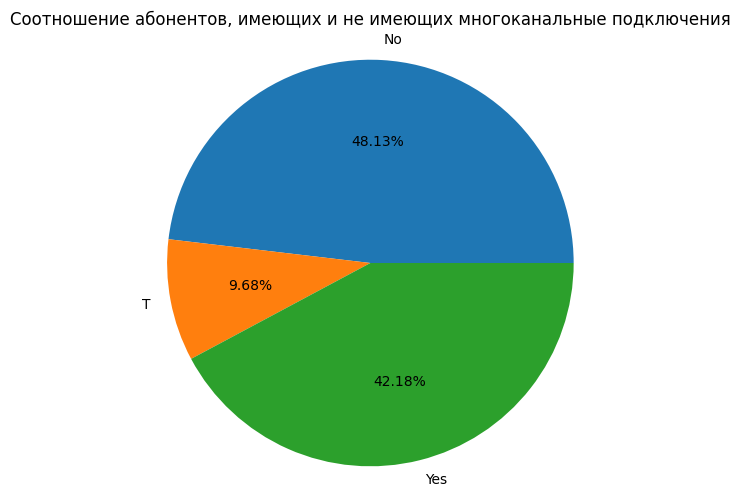

In [69]:
multiple_lines_df.plot(title='Соотношение абонентов, имеющих и не имеющих многоканальные подключения', kind='pie', autopct=lambda x: f'{x:.2f}%', ylabel='', radius=1.1, grid=True, figsize=(15, 6));

Одновременное подключение к нескольим линиям доступно 42% абонентов

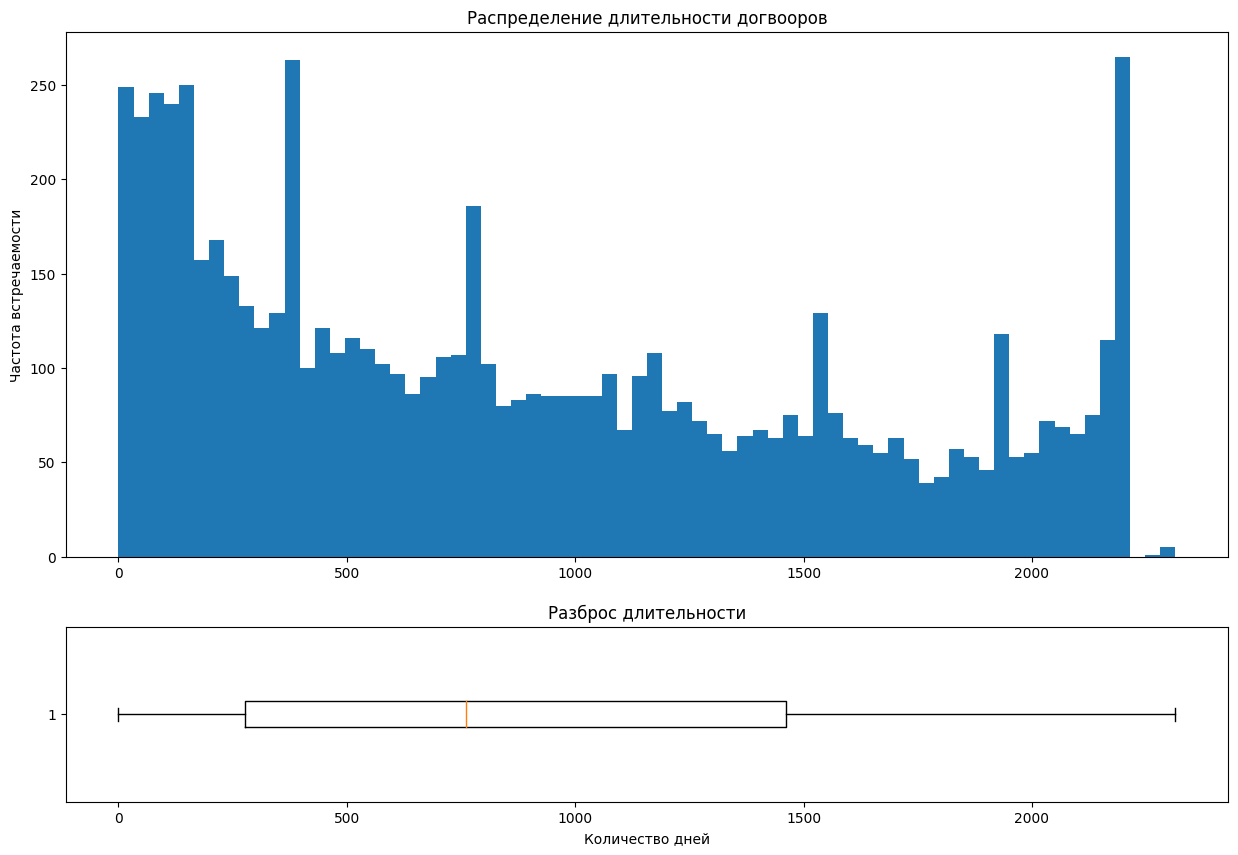

In [70]:
show_hist_boxplot(df.DurationContract, bins=70,
                  hist_title='Распределение длительности догвооров',
                  hist_ylabel='Частота встречаемости',
                  bp_title='Разброс длительности', bp_xlabel='Количество дней')

Новых клиентов несколько больше, чем старых

In [71]:
target_df = df.groupby('Target')['Target'].count()
target_df

Target
0    5942
1    1101
Name: Target, dtype: int64

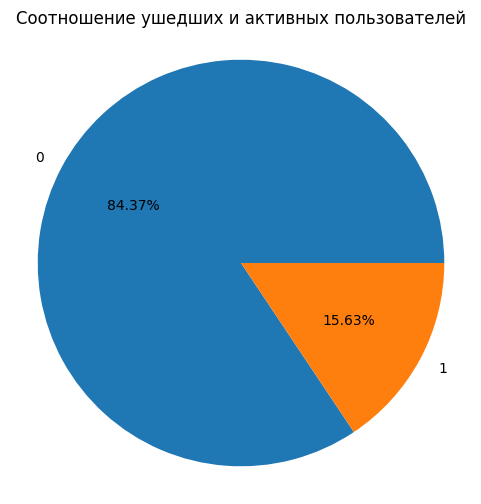

In [72]:
target_df.plot(title='Соотношение ушедших и активных пользователей', kind='pie', autopct=lambda x: f'{x:.2f}%', ylabel='', radius=1.1, grid=True, figsize=(15, 6));

Видим значительный дисбаланс целевого признака

In [73]:
def show_ratio(df: pd.DataFrame,
               data_column: str,
               target_column: str = 'Target',
               title: str = None,
               xlabel: str = None,
               ylabel: str = None) -> None:

    result = df.groupby(target_column)[data_column].value_counts().unstack()
    result = result.div(result.sum(axis=1), axis=0) * 100

    ax = result.plot(kind='bar', figsize=(15, 8))
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(title=data_column)

    for p in ax.patches:
        ax.annotate(f'{p.get_height():.0f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 4),
                    textcoords='offset points')

    plt.show()

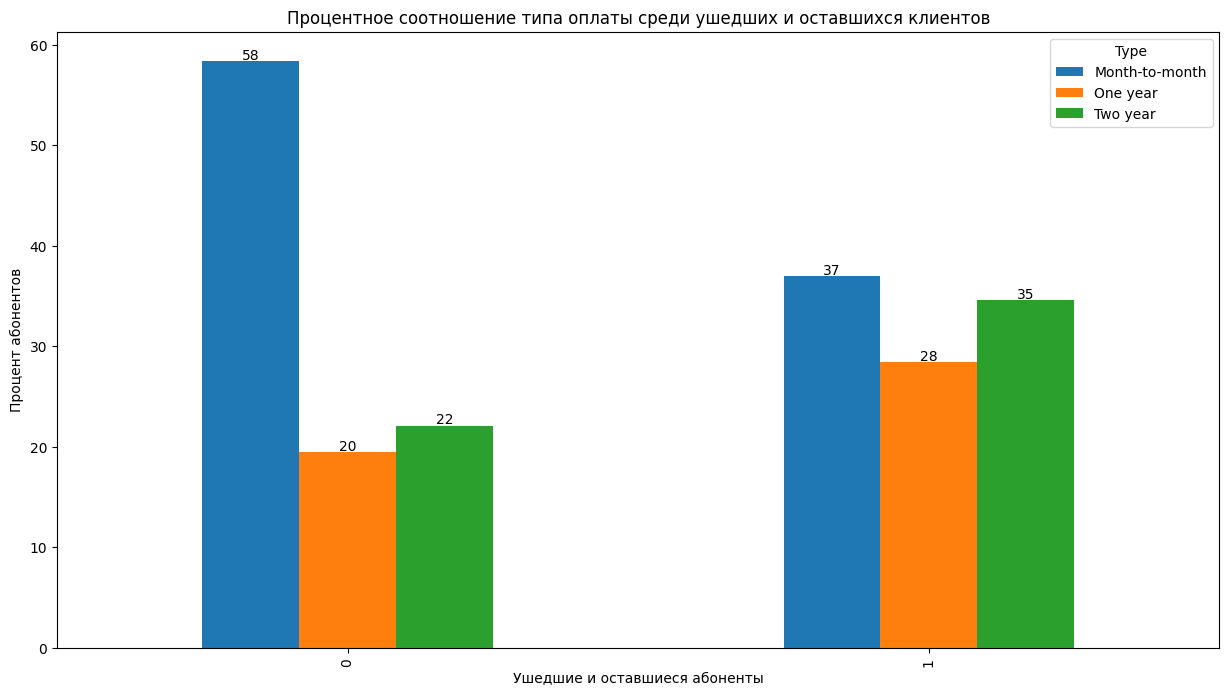

In [74]:
show_ratio(df=df, data_column='Type',
           title='Процентное соотношение типа оплаты среди ушедших и оставшихся клиентов',
           xlabel='Ушедшие и оставшиеся абоненты',
           ylabel='Процент абонентов')

Глядя на график, можно увидеть, что активные пользователи предпочитают ежемесячную оплату другим способам

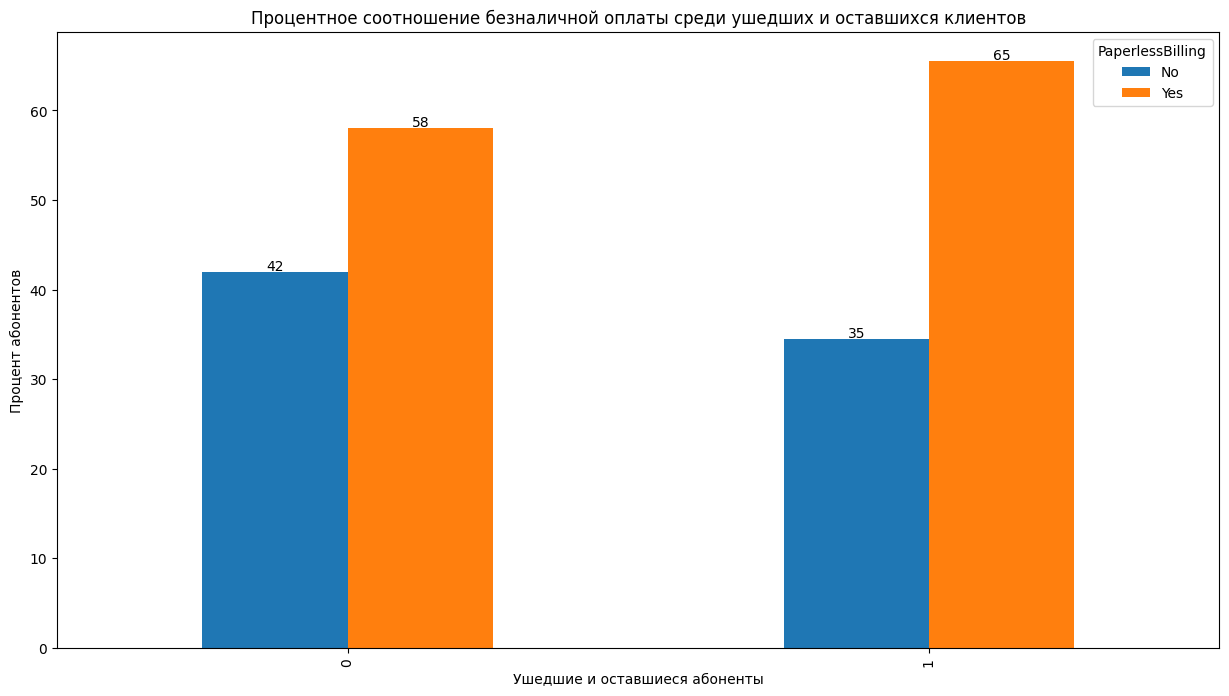

In [75]:
show_ratio(df=df, data_column='PaperlessBilling',
           title='Процентное соотношение безналичной оплаты среди ушедших и оставшихся клиентов',
           xlabel='Ушедшие и оставшиеся абоненты',
           ylabel='Процент абонентов')

Данные говорят, что среди ушедших пользователей было немногим больше тех, кто предпочитал получать счета электронным способом.

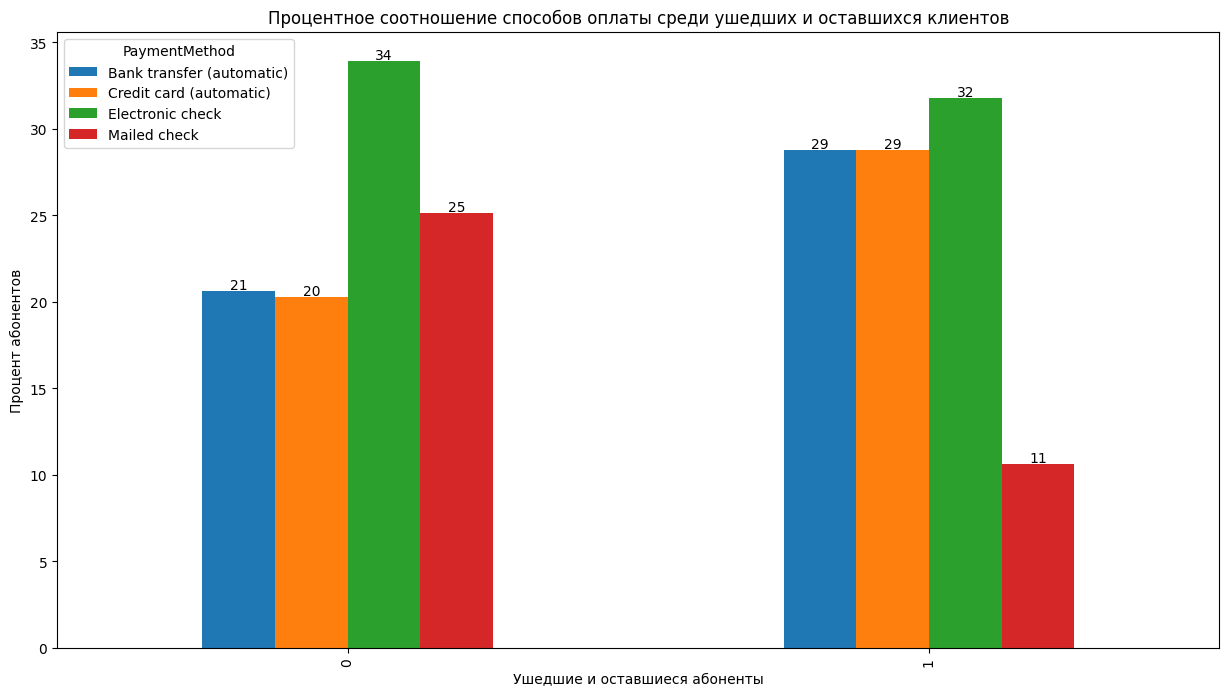

In [76]:
show_ratio(df=df, data_column='PaymentMethod',
           title='Процентное соотношение способов оплаты среди ушедших и оставшихся клиентов',
           xlabel='Ушедшие и оставшиеся абоненты',
           ylabel='Процент абонентов')

Рассматривая способы оплаты, можно отметить, что ушедшие клиенты больше пользовались банковскими переводами и картами для оплаты счетов.

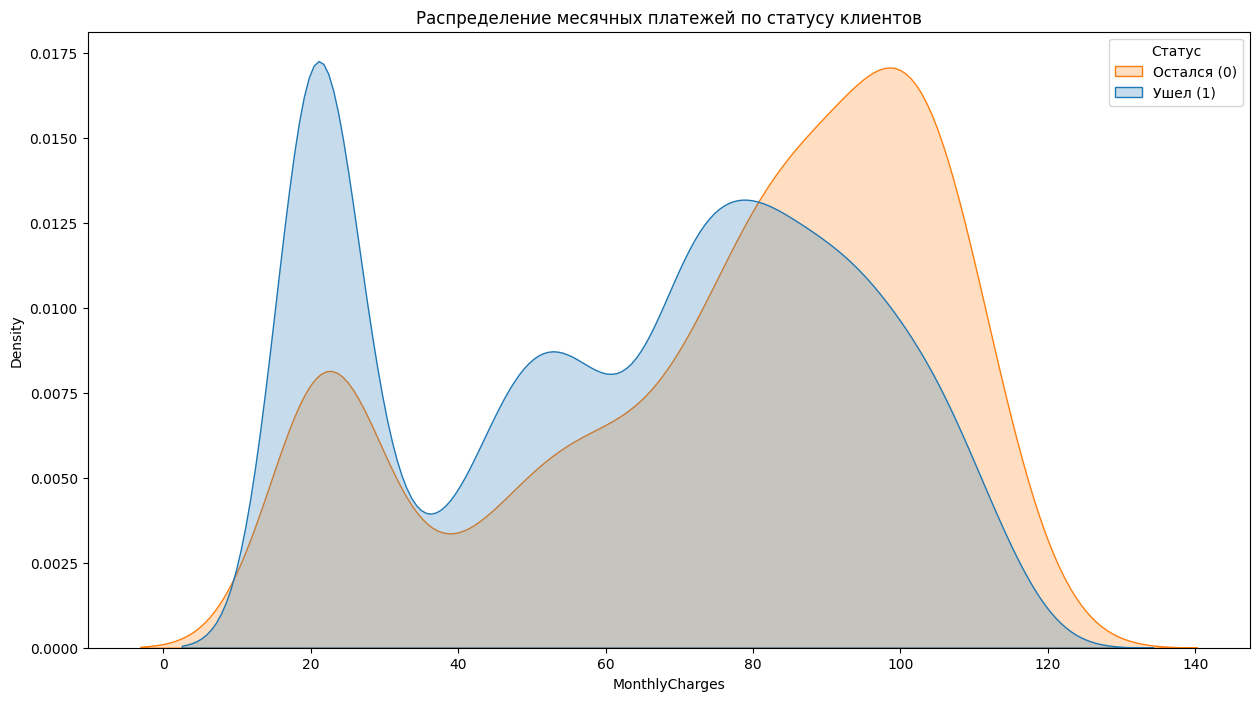

In [77]:
plt.figure(figsize=(15, 8))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Target', fill=True, common_norm=False)
plt.title('Распределение месячных платежей по статусу клиентов')
plt.legend(title='Статус', labels=['Остался (0)', 'Ушел (1)'])
plt.show()

Среди тех, кто отказался от обслуживания, было много людей с дорогостоящими тарифами.

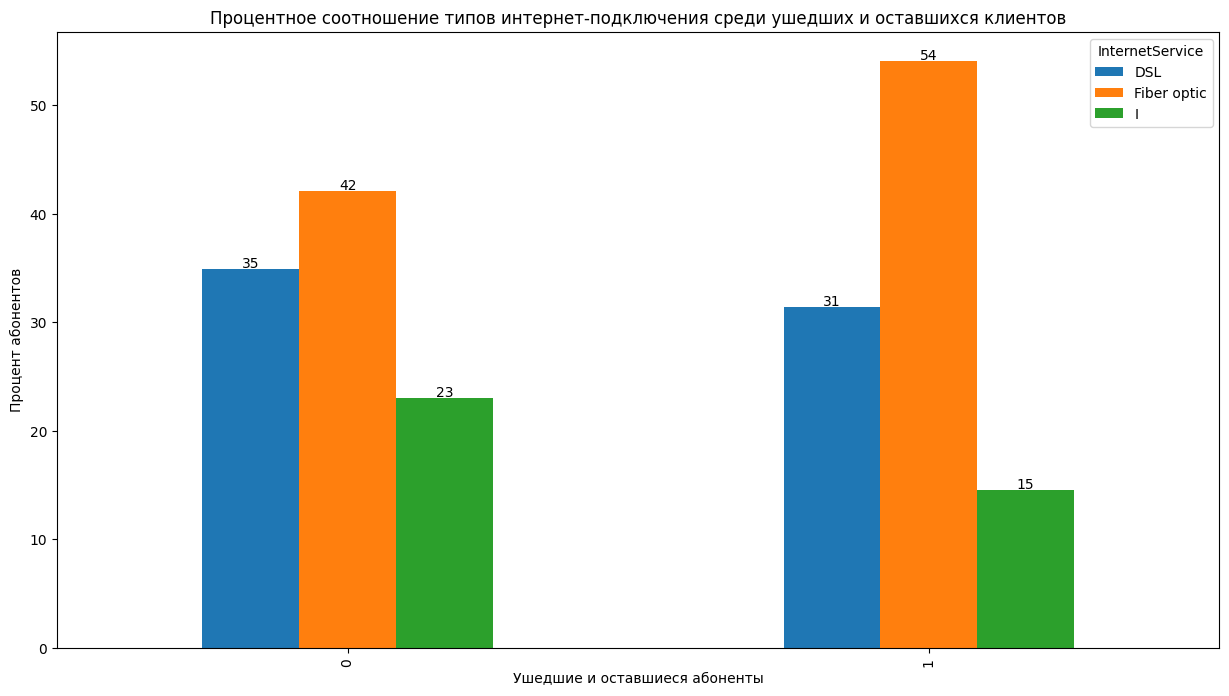

In [78]:
show_ratio(df=df, data_column='InternetService',
           title='Процентное соотношение типов интернет-подключения среди ушедших и оставшихся клиентов',
           xlabel='Ушедшие и оставшиеся абоненты',
           ylabel='Процент абонентов')

Среди отказавшихся от обслуживания клиентов был большой процент использовавших оптоволокно

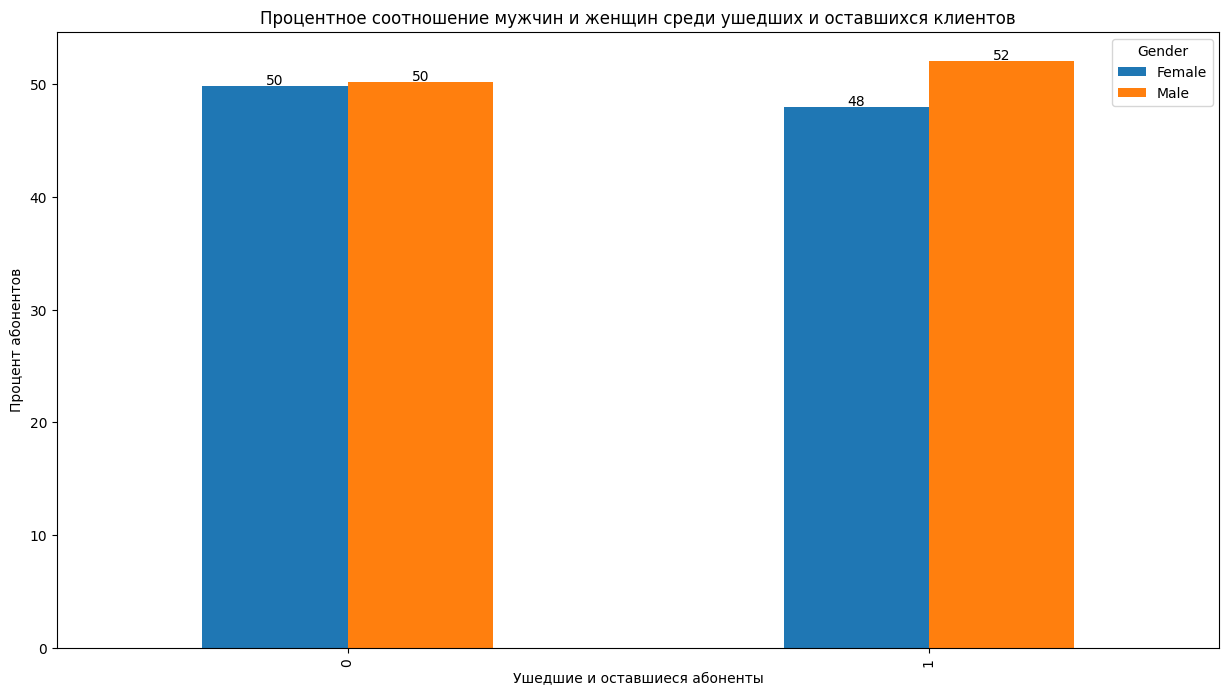

In [79]:
show_ratio(df=df, data_column='Gender',
           title='Процентное соотношение мужчин и женщин среди ушедших и оставшихся клиентов',
           xlabel='Ушедшие и оставшиеся абоненты',
           ylabel='Процент абонентов')

Среди ушедших пользователей мужчин было на 4% больше, среди активных соотношение одинаковое.

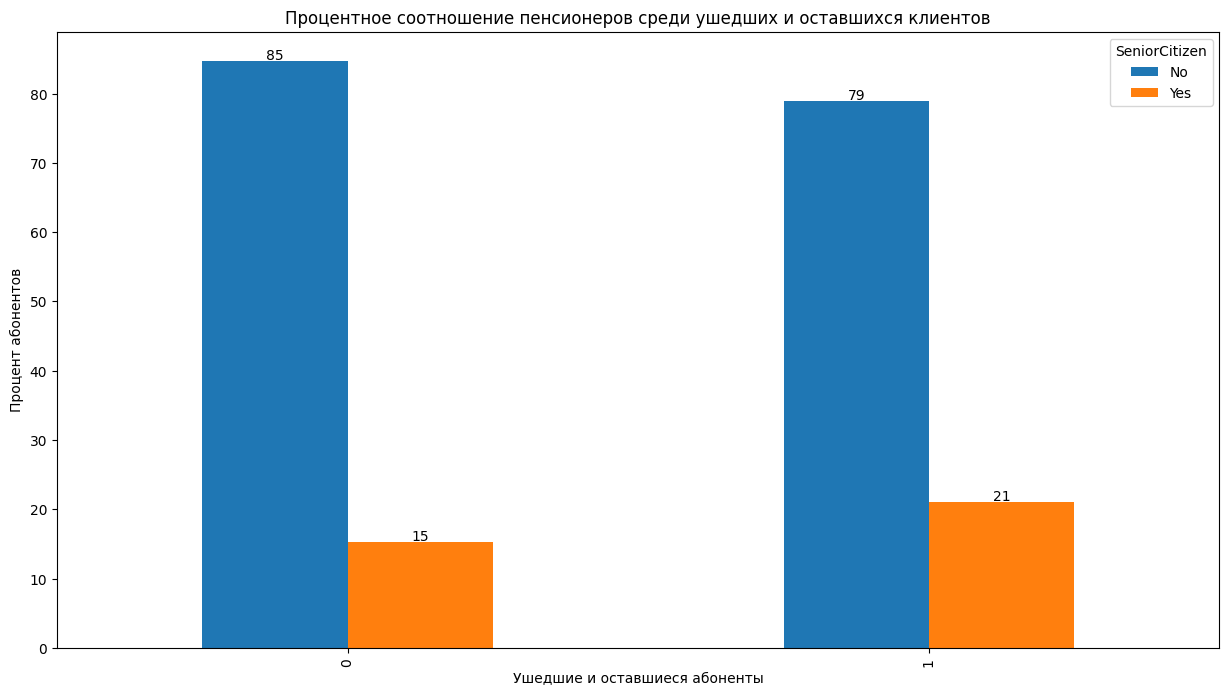

In [80]:
show_ratio(df=df, data_column='SeniorCitizen',
           title='Процентное соотношение пенсионеров среди ушедших и оставшихся клиентов',
           xlabel='Ушедшие и оставшиеся абоненты',
           ylabel='Процент абонентов')

Среди активных пользователей немногим больше людей, не являющихся пенсионерами.

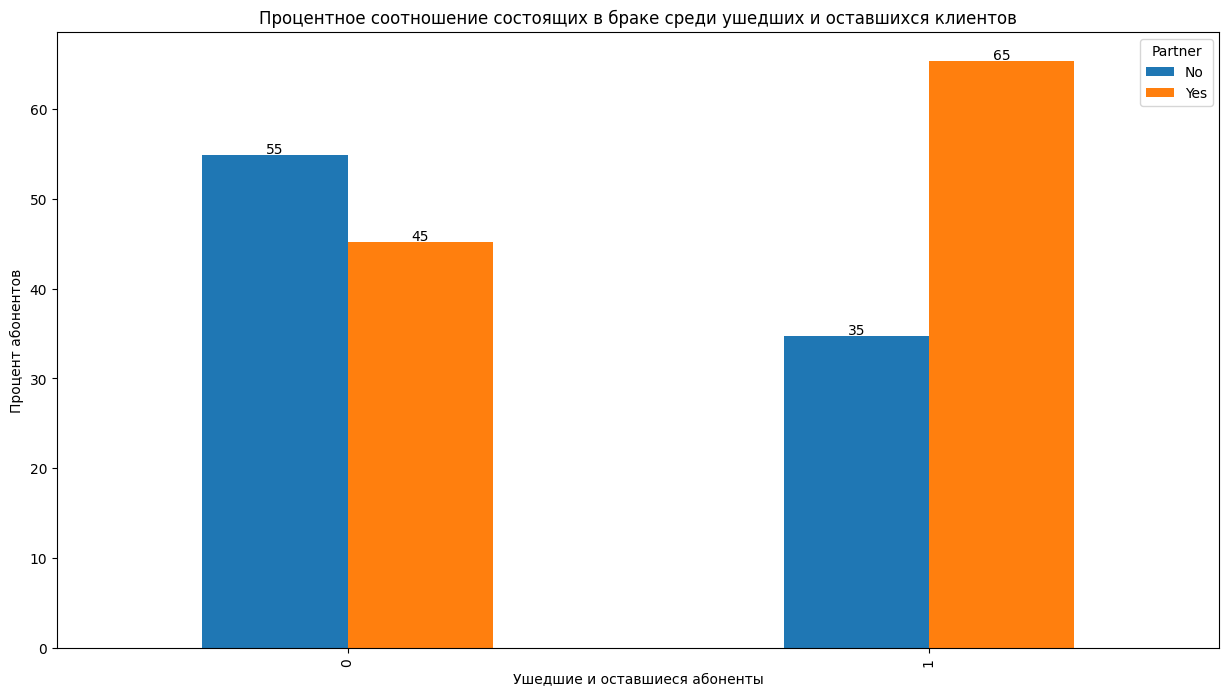

In [81]:
show_ratio(df=df, data_column='Partner',
           title='Процентное соотношение состоящих в браке среди ушедших и оставшихся клиентов',
           xlabel='Ушедшие и оставшиеся абоненты',
           ylabel='Процент абонентов')

Среди активных пользователей больше тех, кто без партнёра.

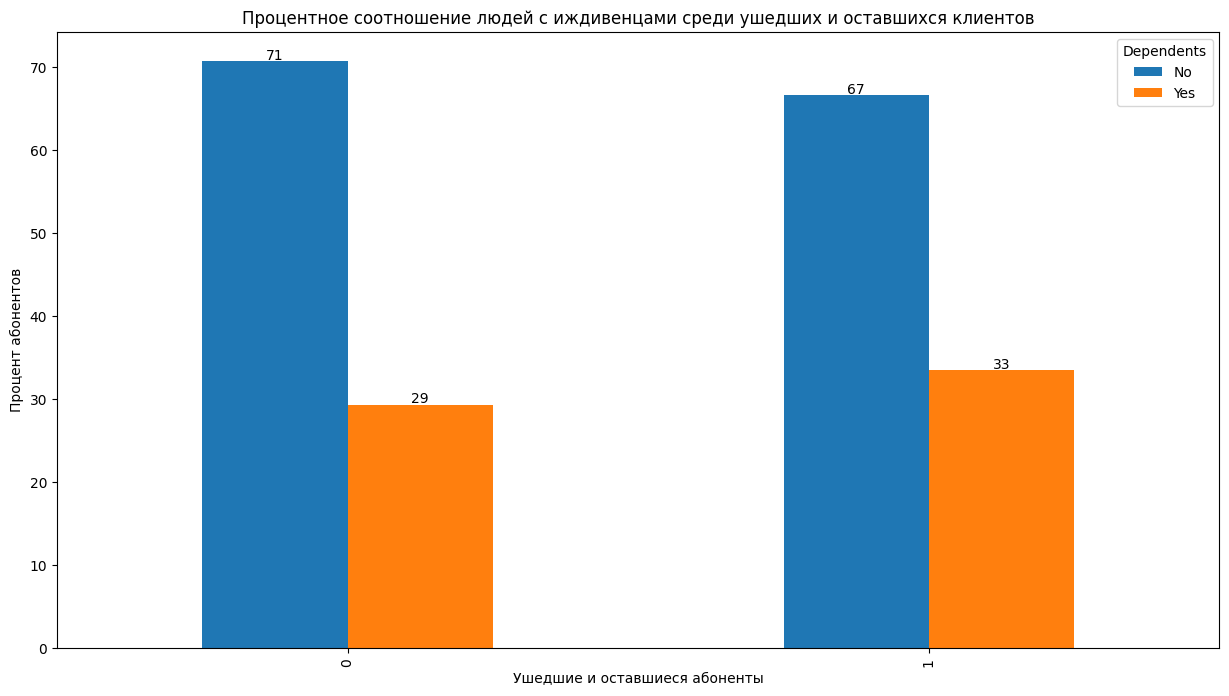

In [82]:
show_ratio(df=df, data_column='Dependents',
           title='Процентное соотношение людей с иждивенцами среди ушедших и оставшихся клиентов',
           xlabel='Ушедшие и оставшиеся абоненты',
           ylabel='Процент абонентов')

Наличие маленьких детей, как видно, не оказывает сильного влияния на целевой признак.

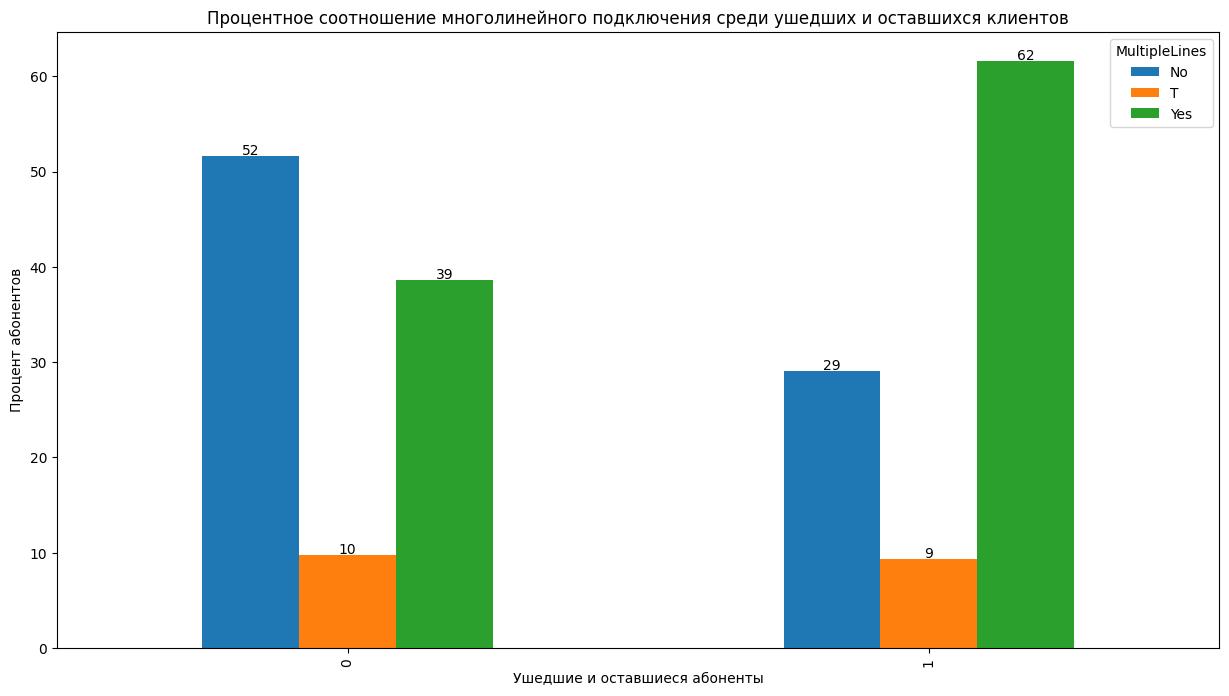

In [83]:
show_ratio(df=df, data_column='MultipleLines',
           title='Процентное соотношение многолинейного подключения среди ушедших и оставшихся клиентов',
           xlabel='Ушедшие и оставшиеся абоненты',
           ylabel='Процент абонентов')

Соотношение пользователей подключения с несколькими линиями почти зеркало относительно того, активен абонент или разорвал договор.

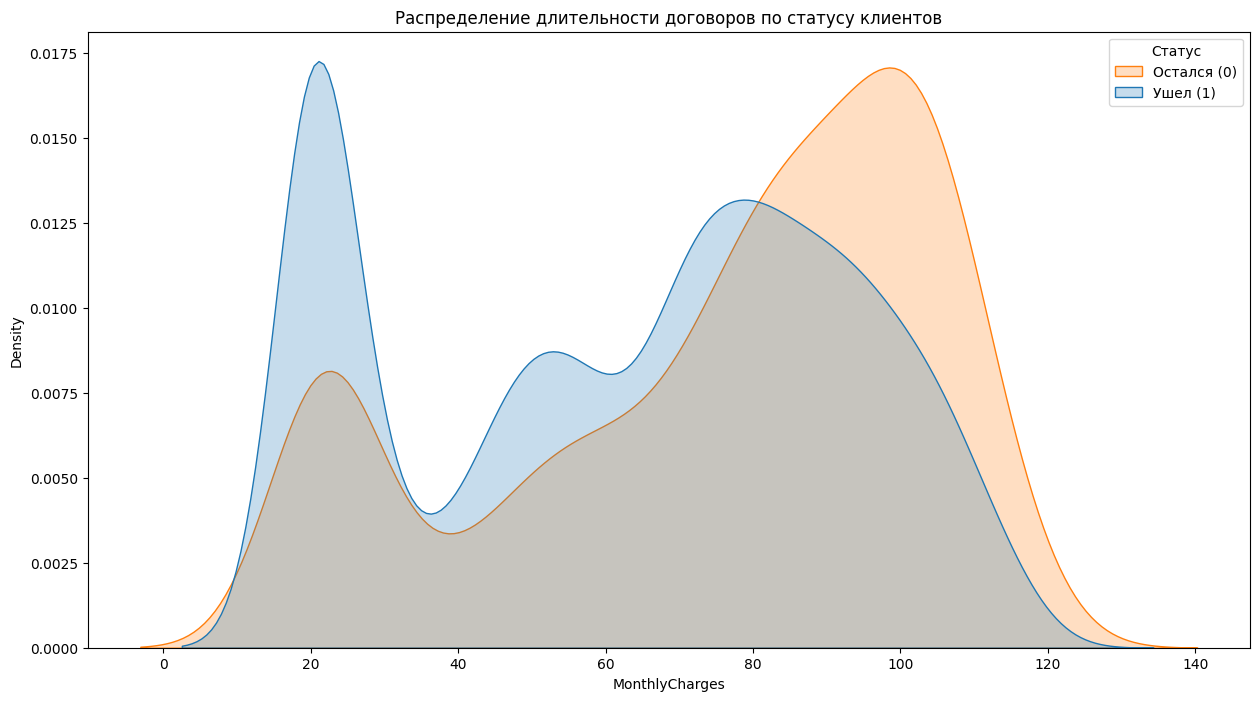

In [84]:
plt.figure(figsize=(15, 8))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Target', fill=True, common_norm=False)
plt.title('Распределение длительности договоров по статусу клиентов')
plt.legend(title='Статус', labels=['Остался (0)', 'Ушел (1)'])
plt.show()

Активные пользователи давно пришли и никуда не уходят.

### Корреляционный анализ данных

Назначим индексом значение столбца `CustomerId` удалим столбцы `BeginDate`, `EndDate`

In [85]:
df.set_index('CustomerId', inplace = True)
df.drop(['BeginDate', 'EndDate'], axis=1, inplace=True)

In [86]:
interval_cols = ['MonthlyCharges', 
                 'TotalCharges', 
                 'DurationContract'
                ]

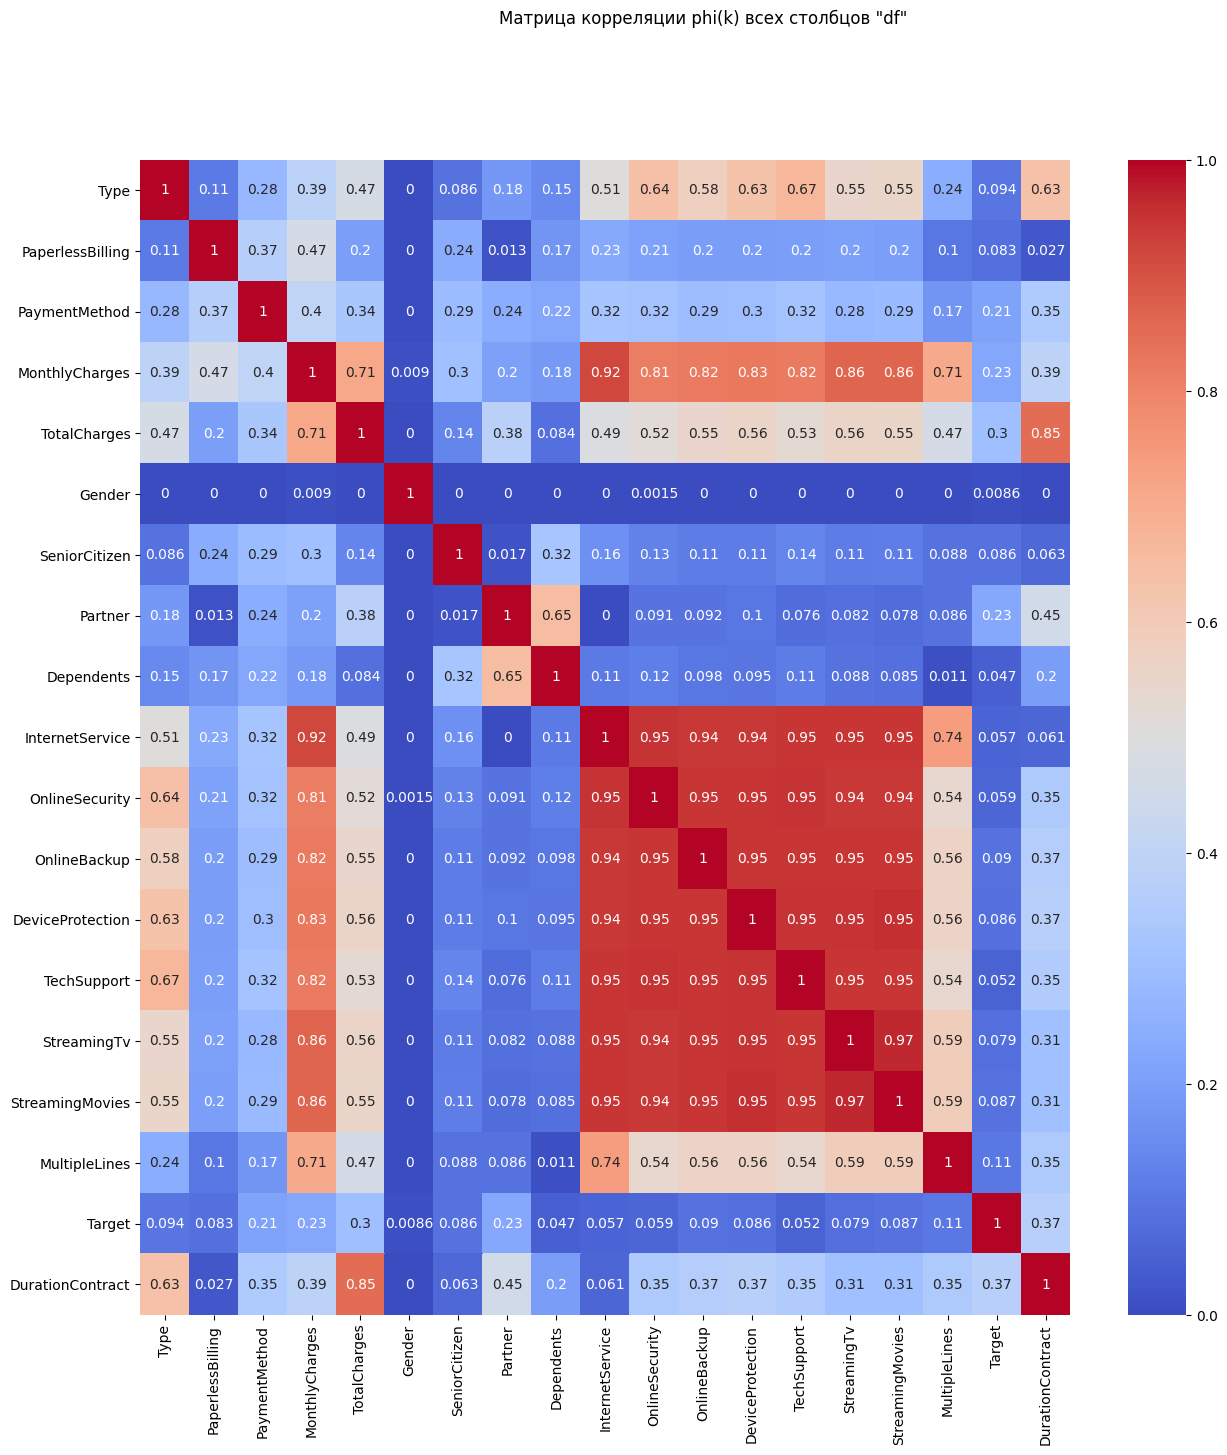

In [87]:
fig, ax = plt.subplots(figsize=(15, 15))
plt.suptitle('Матрица корреляции phi(k) всех столбцов "df"')
sns.heatmap(df.phik_matrix(interval_cols=interval_cols), annot=True, cmap='coolwarm');

По матрице корреляции видно, что отсутствуют сильно коррелирующие показатели с целевым значением.
Присутствует большое количество показателей с мультиколлениарностью (есть значения более 0.9) от которых необходимо избавиться.
Отберем показатели коррелирующие с целевым показателем `Target` по убывающей:
1. 0.37 DurationContract
2. 0.3 TotalCharges
3. 0.23 MonthlyCharges
4. 0.23 Partner
5. 0.21 PaymentMethod
6. 0.11 MultipleLines
7. 0.094 Type
8. 0.09 OnlineBackup

Остальные значения удалим как малозначимые и построим заново матрицу корреляции

In [88]:
df.drop(['PaperlessBilling', 'Gender', 'SeniorCitizen',  
         'Dependents', 'InternetService', 'OnlineSecurity', 'DeviceProtection',
         'TechSupport', 'StreamingTv', 'StreamingMovies'], axis=1, inplace=True)

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Type              7043 non-null   object 
 1   PaymentMethod     7043 non-null   object 
 2   MonthlyCharges    7043 non-null   float64
 3   TotalCharges      7043 non-null   float64
 4   Partner           7043 non-null   object 
 5   OnlineBackup      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   Target            7043 non-null   int64  
 8   DurationContract  7043 non-null   int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 550.2+ KB


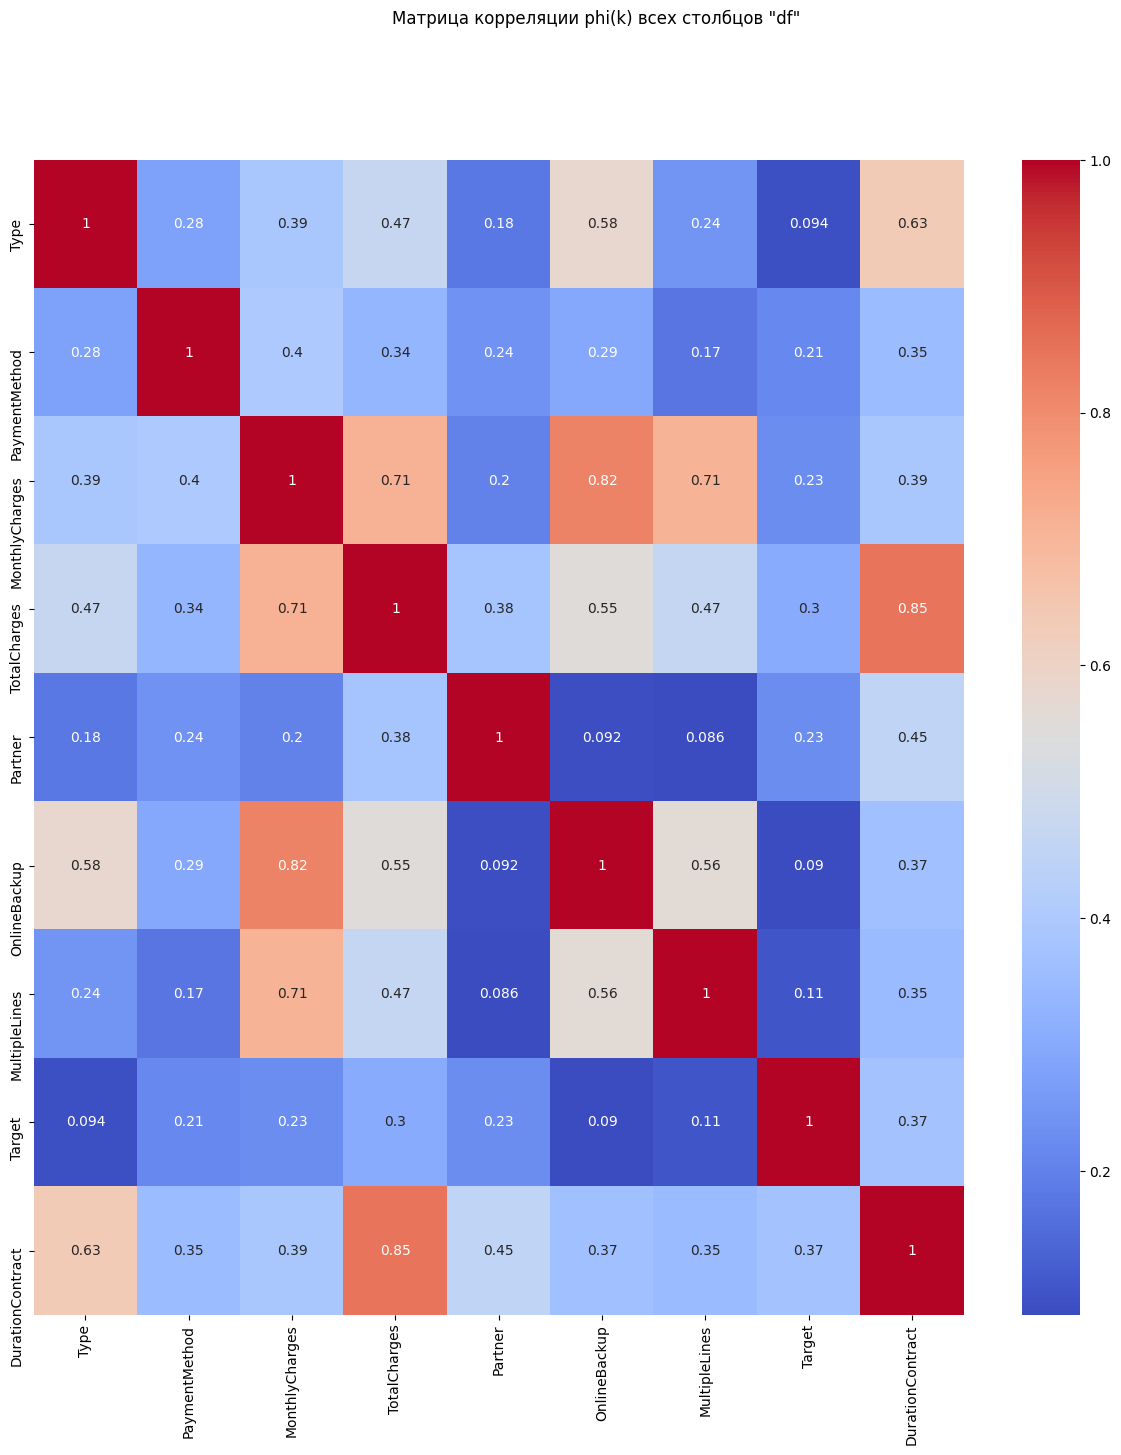

In [90]:
fig, ax = plt.subplots(figsize=(15, 15))
plt.suptitle('Матрица корреляции phi(k) всех столбцов "df"')
sns.heatmap(df.phik_matrix(interval_cols=interval_cols), annot=True, cmap='coolwarm');

#### Результаты корреляционного анализа данных

Мы выполнили предварительную обработку данных:

* Назначили CustomerId в качестве индекса.
* Убрали столбцы BeginDate и EndDate.
* Определили интервальные столбцы для корректных вычислений.

В предварительной матрице корреляции:

* Не обнаружено сильных связей с целевым показателем.
* Выявлено значительное количество мультиколлинеарных признаков (коэффициенты более 0,9).

Выбрали показатели, коррелирующие с целевым значением Target, по убыванию:

* 0,37 — DurationContract.
* 0,3 — TotalCharges.
* 0,23 — MonthlyCharges и Partner.
* 0,21 — PaymentMethod.
* 0,11 — MultipleLines.
* 0,094 — Type.
* 0,09 — OnlineBackup.

Остальные показатели удалили как несущественные. Построили новую матрицу корреляции и проверили отсутствие мультиколлинеарности.

Анализ готов к следующему этапу работы.

## Подготовка данных

Приведем столбцы с категориями к типу `categotry`

In [91]:
cat_col_names = ['Type', 'PaymentMethod', 'Partner', 'OnlineBackup', 'MultipleLines']
num_col_names = ['MonthlyCharges', 'TotalCharges', 'DurationContract']
df[cat_col_names] = df[cat_col_names].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Type              7043 non-null   category
 1   PaymentMethod     7043 non-null   category
 2   MonthlyCharges    7043 non-null   float64 
 3   TotalCharges      7043 non-null   float64 
 4   Partner           7043 non-null   category
 5   OnlineBackup      7043 non-null   category
 6   MultipleLines     7043 non-null   category
 7   Target            7043 non-null   int64   
 8   DurationContract  7043 non-null   int64   
dtypes: category(5), float64(2), int64(2)
memory usage: 310.2+ KB


Разделим на обучающую и тренировочную выборки в соотношении 3:1
Отделим целевой признак

In [92]:
#отделим целевой признак
X = df.drop(columns='Target', axis=1)
y = df['Target']

# Разделение на тренировочную, тестовую выборку
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, 
    random_state=RANDOM_STATE
) 
print('train/test = ', round(X_train.shape[0] / X.shape[0], 2), '/', round(X_test.shape[0] / X.shape[0], 2))

train/test =  0.75 / 0.25


Подготовим пайплан для кодирования признаков

In [93]:
ohe_pipe = Pipeline([
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False))
])

In [94]:
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, cat_col_names),
     ('num', StandardScaler(), num_col_names)
    ], 
    remainder='passthrough'
)

#### Вывод по подготовке данных

- Ктегориальным признакам назначен тип `category`
- Разделили данные на обучающую и тренировочную выборки в соотношении 3:1
- Отделили целевой признак
- Подготовили пайплайн для кодирования признаков

## Обучение моделей машинного обучения

В целях оценки качества модели выберем ROC-AUC c порогом отсечки >= 0.85

*Справка:*

- Кривая ROC — это график, который иллюстрирует производительность классификационной модели при всех возможных порогах классификации.
- Показатель AUC (Area Under the ROC Curve) — это мера, которая позволяет суммировать производительность модели одним числом, измеряя площадь под кривой ROC.
- AUC колеблется от 0 до 1, где более высокое значение AUC указывает на более высокую производительность модели. AUC, равный 0.5, указывает на отсутствие дискриминационной способности модели, тогда как AUC, равный 1.0, означает идеальное различие классов.

### RandomForestClassifier

In [95]:
# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', RandomForestClassifier(random_state=RANDOM_STATE))
])

param_grid = [
    # словарь для модели RandomForestClassifier)
    {
        'models__max_depth': range(4, 21, 4),
        'models__min_samples_leaf': range(1, 11, 1),
        'models__n_estimators': [10, 50, 100],
        'models__class_weight' : [None, 'balanced'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
        
    }
      
]

In [96]:
%%time
rfc = RandomizedSearchCV(
                         pipe_final, 
                         param_grid, 
                         cv=5,
                         scoring='roc_auc',
                         random_state=RANDOM_STATE,
                         n_jobs=-1
).fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', rfc.best_estimator_)
print ('Метрика ROC-AUC лучшей модели на крос валидации:', rfc.best_score_)

/home/administrator/anaconda3/envs/practicum_22_2/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/home/administrator/anaconda3/envs/practicum_22_2/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/home/administrator/anaconda3/envs/practicum_22_2/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/home/administrator/anaconda3/envs/practicum_22_2/lib/python3.9/site-package

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse=False))]),
                                                  ['Type', 'PaymentMethod',
                                                   'Partner', 'OnlineBackup',
                                                   'MultipleLines']),
                                                 ('num', MinMaxScaler(),
                                                  ['MonthlyCharges',
                                                   'TotalCharges',
           

### LGBMClassifier

In [97]:
lgb_model = LGBMClassifier(random_state=RANDOM_STATE)

In [98]:
%%time
lgbm_params = {
               #'learning_rate': [0.0005, 0.001, 0.01, 0.05, 0.1],
                'learning_rate': [0.05, 0.1],
               #'n_estimators': [100, 200, 300, 500],
                'n_estimators': [100, 200],
               #'num_leaves': [31, 71, 101, 151],
               #'class_weight': [None, 'balanced']
    
              }

lgbmс = RandomizedSearchCV(lgb_model, 
                           lgbm_params, 
                           cv=5,
                           scoring='roc_auc',
                           random_state=RANDOM_STATE,
                           n_jobs=-1
).fit(X_train, y_train)


print('Лучшая модель и её параметры:\n\n', lgbmс.best_estimator_)
print ('Метрика ROC-AUC лучшей модели на крос валидации:', lgbmс.best_score_)

[LightGBM] [Info] Number of positive: 809, number of negative: 4473
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000285 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 709
[LightGBM] [Info] Number of data points in the train set: 5282, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.153162 -> initscore=-1.710016
[LightGBM] [Info] Start training from score -1.710016
Лучшая модель и её параметры:

 LGBMClassifier(n_estimators=200, random_state=120126)
Метрика ROC-AUC лучшей модели на крос валидации: 0.8777143365782696
CPU times: user 3.32 s, sys: 747 ms, total: 4.06 s
Wall time: 11min 15s


### CatBoostClassifier

In [99]:
cbc_model = CatBoostClassifier(random_state=RANDOM_STATE, cat_features=cat_col_names, verbose=50)

In [100]:
%%time
cbrm_params = {
               'max_depth': [4, 8],
               'learning_rate': [0.005, 0.01, 0.1],
               'n_estimators': [100, 200]
              }

cbc = RandomizedSearchCV(cbc_model,
                             cbrm_params,
                             cv=5,
                             scoring='roc_auc',
                             random_state=RANDOM_STATE,
                             n_jobs=-1).fit(X_train, y_train)

print ('Метрика ROC-AUC лучшей модели на крос валидации:', cbc.best_score_)

0:	learn: 0.6226598	total: 61ms	remaining: 12.1s
50:	learn: 0.2850383	total: 579ms	remaining: 1.69s
100:	learn: 0.2552768	total: 1.11s	remaining: 1.08s
150:	learn: 0.2187775	total: 1.74s	remaining: 565ms
199:	learn: 0.1884164	total: 2.36s	remaining: 0us
Метрика ROC-AUC лучшей модели на крос валидации: 0.8617442106661042
CPU times: user 11.6 s, sys: 6.97 s, total: 18.6 s
Wall time: 50 s


#### Вывод по обучению моделей

- В целях оценки качества модели выберали показатель ROC-AUC c порогом отсечки >= 0.85
- Провели обучение следующих моделей:
    - `RandomForestClassifier`
    - `LGBMClassifier`
    - `CatBoostClassifier`
    
Перейдем к выбору лучшей модели

## Выбор лучшей модели

Отберем лучшую модель по показателю на кросс-валидации по условию ROC-AUC >= 0.85

In [101]:
results = pd.DataFrame({'Model': ['RandomForestClassifier', 'LGBMClassifier', 'CatBoostClassifier'],
                        'ROC_AUC_Valid': [rfc.best_score_, lgbmс.best_score_, cbc.best_score_],
                        'Cod':['rfc','lgbmс','cbc']})
results

,Model,ROC_AUC_Valid,Cod
0,RandomForestClassifier,0.817402,rfc
1,LGBMClassifier,0.877714,lgbmс
2,CatBoostClassifier,0.861744,cbc


In [102]:
results = results[results['ROC_AUC_Valid']>=0.85].sort_values('ROC_AUC_Valid', ascending=False).head(1)
results

,Model,ROC_AUC_Valid,Cod
1,LGBMClassifier,0.877714,lgbmс


Проведем оценку модели на тестовой выборке

In [103]:
models_with_scores = [
    (rfc, rfc.best_score_),
    (lgbmс, lgbmс.best_score_),
    (cbc, cbc.best_score_)
]

def select_best_model(models_with_scores):
    
    if not models_with_scores:
        raise ValueError("Список моделей пуст!")
    
    best_pair = max(models_with_scores, key=lambda x: x[1])
    best_model, best_score = best_pair
    
    print(f"Лучшая модель: {best_model.best_estimator_}")
    print(f"Лучший score: {best_score:.4f}")
    
    return best_model

best_model = select_best_model(models_with_scores)

Лучшая модель: LGBMClassifier(n_estimators=200, random_state=120126)
Лучший score: 0.8777


In [104]:
roc_auc_test = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])
print("ROC-AUC лучшей модели на кросс-валидации: %.5f" % best_model.best_score_)
print("ROC-AUC лучшей модели на тестовой выборке: %.5f" % roc_auc_test)
print(f'Потеря качества лучшей модели на тестовой выборке по отношению к валидационной: {((roc_auc_test - best_model.best_score_)/best_model.best_score_*100):.3f} %' )

ROC-AUC CatBoostClassifier на кросс-валидации: 0.87771
ROC-AUC CatBoostClassifier на тестовой выборке: 0.90115
Потеря качества лучшей модели на тестовой выборке по отношению к валидационной: 2.670 %


In [105]:
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE).fit(X_train, y_train)

print(f'Значение ROC-AUC "DummyClassifier" на тестовой выборке: {roc_auc_score(y_test, dummy_clf.predict_proba(X_test)[:, 1]):.3f}')
print(f'Метрика ROC-AUC на тестовой выборке: {best_model.score(X_test, y_test):.3f}')
print(f'Значение ROC-AUC выбранной модели на тестовой выборке лучше "DummyClassifier" в : {(best_model.score(X_test, y_test) / roc_auc_score(y_test, dummy_clf.predict_proba(X_test)[:, 1])):.3f} раз')

Значение ROC-AUC "DummyClassifier" на тестовой выборке: 0.500
Метрика ROC-AUC на тестовой выборке: 0.901
Значение ROC-AUC выбранной модели на тестовой выборке лучше "DummyClassifier" в : 1.802 раз


Проведем построение графика ROC кривой для сравнения со средним значением 0.5 (указывает на отсутствие дискриминационной способности модели)

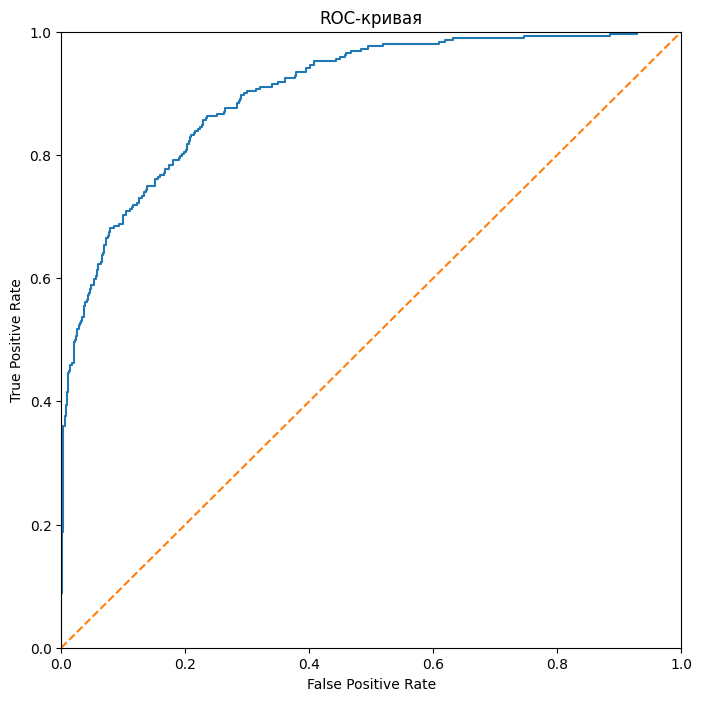

In [106]:
fpr, tpr, thresholds = roc_curve(y_test, best_model.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.show();

Проведенное сравнение указывает, что работа принесла положительный эффект.

Проведем анализ важности признаков выбранной модели

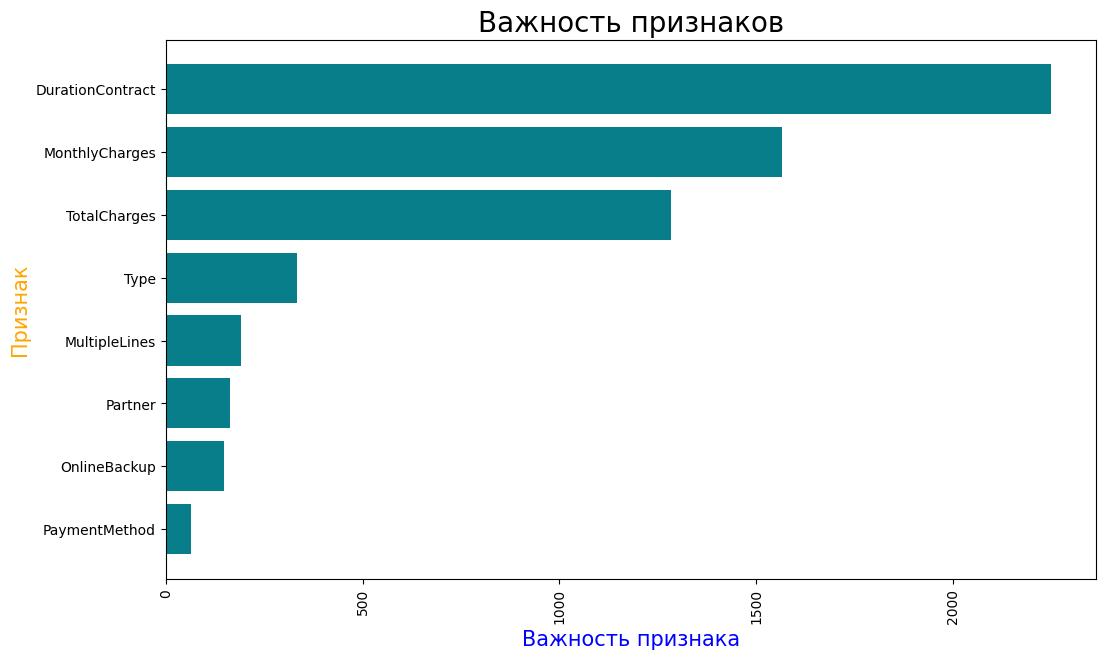

In [107]:
importances = pd.DataFrame(data={'Attribute': X.columns,'Importance': best_model.best_estimator_.feature_importances_})
importances = importances.sort_values(by='Importance', ascending=True)
plt.figure(figsize=(12, 7))
plt.barh(y=importances['Attribute'], width=importances['Importance'], color='#087E8B')
plt.title('Важность признаков', size=20)
plt.xticks(rotation='vertical')
plt.xlabel('Важность признака', fontsize=15, color='blue')
plt.ylabel('Признак', fontsize=15, color='orange')
plt.show();

Данный график можно интерпретировать следующим образом:
- Наиболее значимый признак влияющий на целевой показатель `DurationContract` - длительность контракта в днях, созданный на основе даты заключения контракта и его рассторжения. Влияние на целевой признак значительно и превышает остальные признаки более чем в 4 раза
- Далее по убывающей `Type` - тип оплаты, `MonthlyCharges` - месячные затраты, `TotalCharges` - общие траты клиента накопительным итогом, `MultipleLines` - мульти телефонная линия, `Partner` - наличие детей у клиента, `PaymentMethod` - метод оплаты и в конце `OnlineBackup` - использование облачного хранилища данных
- Остальные критерии ещё менее значимые.

Для сокращения оттока клиентов можно дополнительно провести влияние длительности контракта на отток клиентов, для поиска оптимального времени предложения промокодов клиентам.

Постоим матрицу ошибок

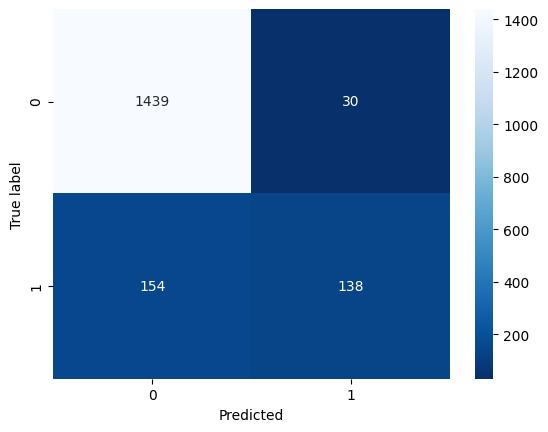

In [108]:
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('True label')
plt.xlabel('Predicted');

Расчитаем показатели матрицы ошибок

In [109]:
acc = accuracy_score(y_test, y_pred)
print('accuracy: ',round(acc,3), '(Доля правильных ответов)')
recall = recall_score(y_test, y_pred)
print('recall: ',round(recall ,3), '(Ошибка FN (False Negative))')
precision = precision_score(y_test, y_pred) 
print('precision: ',round(precision,3), '(Ошибка FP (False Positive))')

accuracy:  0.896 (Доля правильных ответов)
recall:  0.473 (Ошибка FN (False Negative))
precision:  0.821 (Ошибка FP (False Positive))


Интерпретация матрицы ошибок и показателей:

* Accuracy = 0.91 показывает общую точность модели. Этот метрик полезен, когда все классы одинаково важны. Он рассчитывается как отношение правильных прогнозов к их общему числу.
* Recall = 0.453 — это отношение правильно классифицированных положительных выборок к общему числу положительных семплов. Recall оценивает способность модели находить положительные примеры. Чем выше значение, тем больше положительных случаев обнаружено.
* Precision = 0.902 — это отношение корректно распознанных положительных семплов к общему числу предсказанных положительных случаев. Precision оценивает точность модели в определении положительных примеров.

Клиент расторг контракт — это признак 1, который приводит к:

1. Ошибке FN (False Negative), связанной с Recall. Модель ошибочно предсказывает, что клиент останется, хотя он уже ушел. В нашем случае это нежелательно, поэтому важно минимизировать такие ошибки по запросу заказчика.
2. Ошибке FP (False Positive), связанной с Precision. Модель ошибочно предсказывает уход клиента, хотя на самом деле он остаётся. В нашем случае это может быть даже выгодно, но может снизить прибыль от раздачи промокодов.

#### Выбор оптимальной модели

Мы выбрали лучшую модель — CatBoostClassifier — на основе максимального значения ROC-AUC при кросс-валидации. Построили график ROC-кривой, чтобы сравнить её с базовым уровнем 0.5, который указывает на отсутствие дискриминационной способности модели.

Провели анализ важности признаков и дали им интерпретацию. Также построили матрицу ошибок и объяснили её результаты.

Подготовим итоговый отчёт для клиента.

## Общий вывод и рекомендации заказчику

1. Для технических специалистов:

Выводы и порядок работы:

* Выбрана лучшая модель — `CatBoostClassifier`. Её ROC-AUC на тестовой выборке составляет 0.91, что выше порогового уровня 0.85.
* Построена AUC-кривая для визуального анализа дискриминационной способности модели. Значения удовлетворительные.
* Важные признаки модели в убывающем порядке:
  * `DurationContract` — длительность контракта в днях (значительное влияние на целевой признак, превышает остальные более чем в 4 раза).
  * `Type` — тип оплаты.
  * `MonthlyCharges` — месячные затраты.
  * `TotalCharges` — общие траты клиента накопительным итогом.
  * `MultipleLines` — наличие нескольких телефонных линий.
  * `Partner` — количество детей у клиента.
  * `PaymentMethod` — метод оплаты.
  * `OnlineBackup` — использование облачного хранилища данных.
* Построена матрица ошибок и рассчитан показатель `Accuracy` (доля правильных ответов), который составил 0.91 или 91%. Матрица ошибок указывает на наличие ошибок первого и второго рода (recall = 0.352, precision = 0.779). Однако в условиях работы нет требований к их минимизации.

2. Для заказчика:

Цель достигнута:

Модель успешно предсказывает, разорвёт ли абонент договор. Её качество оценивается по `ROC-AUC`, значение которого составляет 0.875 при проверке на тестовой выборке (выше порогового уровня 0.85).

Для интерпретации результатов рассчитан показатель `Accuracy` лучшей модели. Он указывает на долю правильных ответов в предсказании и составляет 0.91 (91%).

Теперь оператор связи «ТелеДом» сможет бороться с оттоком клиентов, предлагая промокоды и специальные условия тем, кто планирует отказаться от услуг.

Рекомендации для бизнеса по снижению оттока клиентов

1. Разработана и внедрена модель, выявляющая клиентов, готовых расторгнуть договор. Это поможет оператору «ТелеДом» предлагать промокоды и специальные условия тем, кто собирается уйти.
2. Собрать максимум данных и повторно проанализировать их после внедрения модели.
3. Дополнительно учитывать данные о промокодах и условиях, поскольку клиенты могут уходить после их исчерпания.
4. Создать таблицу с данными о использовании тарифов каждым клиентом. Это поможет анализировать информацию по тарифам и улучшит результаты анализа.
5. Провести опрос клиентов, разрывающих договор. Это даст возможность выявить слабые стороны компании, пусть и в ограниченном объеме.